# F3-D - Estratégia D: tradução direta enriquecida com R3

Este notebook executa a Estratégia D da Fase 3. O fluxo avaliado é:

```text
linguagem natural + demonstrações enriquecidas com R3 → Nile
```

R3 é a justificativa explícita produzida na F2 para explicar a passagem direta entre uma intenção em linguagem natural e sua expressão Nile. Na F3-D, R3 aparece **somente nas demonstrações few-shot do conjunto de treino**. A justificativa R3 do exemplo de teste nunca é fornecida ao modelo aluno.

A estratégia possui duas variantes:

```text
sem_ac
primeira_ac
```

A variante `sem_ac` avalia a primeira saída Nile. A variante `primeira_ac` preserva essa saída quando ela já é aceita sintaticamente e realiza uma única tentativa de autocorreção apenas quando `PSR=0`.

A grade experimental é formada por:

- cinco folds;
- 50 exemplos do CAMPI;
- 40 exemplos de treino e 10 de teste em cada fold;
- `k=1`, `k=3` e `k=5`;
- seleção Aleatória, Lexical e Semântica;
- nove condições-base;
- 450 fluxos-base;
- 900 registros finais, considerando as duas variantes.

A cadeia principal é:

```text
NL de teste
   +
demonstrações de treino: NL + R3 + Nile
   ↓
Qwen2.5-1.5B-Instruct
   ↓
Nile inicial
   ↓
avaliação formal
   ↓
primeira autocorreção somente quando PSR=0
```

O notebook não utiliza a Nile, a IR, R1, R2 ou R3 de referência do exemplo de teste durante a inferência. As demonstrações são as seleções cumulativas congeladas no F3-modelo e excluem exemplos formalmente equivalentes ao teste.

| Bloco | Etapa | Função metodológica | Resultado principal |
|---:|---|---|---|
| 1 | Configuração | Fixar ambiente, caminhos, grade e funções comuns | Base da F3-D |
| 2 | Auditoria | Localizar e verificar o F3-modelo | Entrada operacional íntegra |
| 3 | Carga | Integrar CAMPI, R3, folds, seleções e módulos formais | 50 registros prontos |
| 4 | Plano | Construir os 450 fluxos-base | `f3d_plano_execucao.csv` |
| 5 | Modelo | Carregar o Qwen2.5-1.5B-Instruct | Modelo aluno disponível |
| 6 | Tradução com R3 | Montar, auditar e executar NL + R3 → Nile | 450 saídas iniciais |
| 7 | Autocorreção | Corrigir somente saídas com `PSR=0` | Primeira tentativa registrada |
| 8 | Consolidação | Produzir as variantes `sem_ac` e `primeira_ac` | 900 resultados |
| 9 | Análise | Consolidar métricas, tabelas e gráficos padronizados | Comparações da estratégia |
| 10 | Empacotamento | Aplicar barreiras finais e registrar hashes | `f3d_traducao_com_r3.zip` |

## Bloco 1 - Configuração inicial

### Objetivo

Este bloco prepara o ambiente da F3-D e concentra todas as definições que devem permanecer fixas durante a execução. A centralização impede que caminhos, quantidades, ordem de exibição, limites de geração ou regras de retomada sejam redefinidos em etapas posteriores.

### Configuração experimental

São fixados:

- estratégia `F3-D`;
- variantes `sem_ac` e `primeira_ac`;
- 50 exemplos e cinco folds;
- `k=1`, `k=3` e `k=5`;
- métodos Aleatória, Lexical e Semântica;
- nove condições-base, 450 fluxos e 900 resultados finais;
- semente global `42`;
- geração determinística, sem amostragem;
- máximo de 256 novos tokens para Nile.

### Checkpoints

A tradução inicial e a primeira autocorreção possuem checkpoints independentes. Cada resposta é persistida imediatamente. Um registro anterior só é reutilizado quando seu fingerprint confirma igualdade de prompt, modelo e parâmetros de geração.

### Tabelas e tempos

As tabelas seguem o padrão visual das fases anteriores. Os tempos permanecem armazenados em segundos nos artefatos computacionais, mas são apresentados no notebook em horas, minutos e segundos.

### Resultado esperado

O bloco não executa inferência. Ao final, todos os diretórios, caminhos, funções auxiliares e parâmetros estarão disponíveis.

In [1]:
# ----------------------------------------------------------
# 1.1 Importação das bibliotecas principais
# ----------------------------------------------------------

import gc
import gzip
import hashlib
import importlib.metadata
import json
import os
import platform
import re
import shutil
import sys
import time
import traceback
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


# ----------------------------------------------------------
# 1.2 Identificação da estratégia
# ----------------------------------------------------------

FASE = "F3-D"
ESTRATEGIA = "F3-D"
VARIANTES = ["sem_ac", "primeira_ac"]
NOME_ESTRATEGIA = "Tradução direta enriquecida com R3"
DATASET = "CAMPI"

TOTAL_EXEMPLOS_ESPERADO = 50
TOTAL_FOLDS_ESPERADO = 5
TOTAL_CONDICOES_BASE = 9
TOTAL_CONDICOES_ESPERADO = 18
TOTAL_FLUXOS_BASE_ESPERADO = 450
TOTAL_REGISTROS_ESPERADO = 900
SEED_GLOBAL = 42

K_FEWSHOT = [1, 3, 5]
METODOS_FEWSHOT = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]

ORDEM_METODOS_EXIBICAO = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]
ORDEM_METODOS_MAPA = {
    metodo: posicao
    for posicao, metodo in enumerate(ORDEM_METODOS_EXIBICAO)
}

ORDEM_VARIANTES_EXIBICAO = ["sem_ac", "primeira_ac"]
ORDEM_VARIANTES_MAPA = {
    variante: posicao
    for posicao, variante in enumerate(ORDEM_VARIANTES_EXIBICAO)
}

ROTULOS_VARIANTES = {
    "sem_ac": "Sem autocorreção",
    "primeira_ac": "Primeira autocorreção",
}

ROTULOS_METODOS = {
    "random_seed42": "Aleatória",
    "lexical_tfidf": "Lexical",
    "semantic_embeddings": "Semântica",
}

CORES_METODOS = {
    "random_seed42": "#f2c94c",
    "lexical_tfidf": "#2ca02c",
    "semantic_embeddings": "#1f77b4",
}

METRICAS = ["psr", "em", "ed", "ned", "sla_s", "sla_f"]
ROTULOS_METRICAS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}

AUTOCORRIGIR_APENAS_SINTATICAMENTE_INVALIDAS = True


# ----------------------------------------------------------
# 1.3 Modelo aluno e geração
# ----------------------------------------------------------

MODELO_ALUNO = "Qwen2.5-1.5B-Instruct"
MODELO_HF_ID = "Qwen/Qwen2.5-1.5B-Instruct"
MODELO_LOCAL_HINTS = ["qwen2.5", "1.5b", "instruct"]

USAR_CUDA = True
PERMITIR_DOWNLOAD_HUGGINGFACE = True
MAX_NEW_TOKENS_NILE = 256
DO_SAMPLE = False
LIMITE_CONTEXTO_FALLBACK = 32768


# ----------------------------------------------------------
# 1.4 Controle de execução
# ----------------------------------------------------------

REINICIAR_EXECUCAO = False
MODO_TESTE_RAPIDO = False
TOTAL_REGISTROS_TESTE_RAPIDO = 5
INTERVALO_SNAPSHOT = 25


# ----------------------------------------------------------
# 1.5 Diretórios principais
# ----------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")
RAIZ_TRABALHO = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/mnt/data/f3d_working")
)

F3D_DIR = RAIZ_TRABALHO / "f3d_traducao_com_r3"
ENTRADAS_DIR = F3D_DIR / "entradas"
INTERMEDIARIOS_DIR = F3D_DIR / "intermediarios"
GRAFICOS_DIR = F3D_DIR / "graficos"
PACOTE_DIR = F3D_DIR / "pacote"
F3_MODELO_DIR = ENTRADAS_DIR / "f3_modelo_operacional"

if REINICIAR_EXECUCAO and F3D_DIR.exists():
    shutil.rmtree(F3D_DIR)

for diretorio in [
    F3D_DIR,
    ENTRADAS_DIR,
    INTERMEDIARIOS_DIR,
    GRAFICOS_DIR,
    PACOTE_DIR,
]:
    diretorio.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# 1.6 Caminhos dos artefatos da F3-D
# ----------------------------------------------------------

CONFIG_PATH = PACOTE_DIR / "f3d_config.json"
PLANO_PATH = PACOTE_DIR / "f3d_plano_execucao.csv"

PROMPTS_NILE_PATH = PACOTE_DIR / "f3d_prompts_nile.jsonl.gz"
TOKEN_AUDIT_NILE_PATH = PACOTE_DIR / "f3d_token_audit_nile.csv"
CHECKPOINT_NILE_PATH = INTERMEDIARIOS_DIR / "f3d_checkpoint_nile.jsonl"
GENERATIONS_NILE_PATH = PACOTE_DIR / "f3d_generations_nile.jsonl.gz"
INITIAL_EVALUATION_PATH = PACOTE_DIR / "f3d_initial_evaluation.csv"

PROMPTS_AC_PATH = PACOTE_DIR / "f3d_prompts_autocorrection.jsonl.gz"
TOKEN_AUDIT_AC_PATH = PACOTE_DIR / "f3d_token_audit_autocorrection.csv"
CHECKPOINT_AC_PATH = INTERMEDIARIOS_DIR / "f3d_checkpoint_autocorrection.jsonl"
GENERATIONS_AC_PATH = PACOTE_DIR / "f3d_generations_autocorrection.jsonl.gz"
PROMPT_AUDIT_PATH = PACOTE_DIR / "f3d_prompt_audit.csv"

RESULTS_JSONL_PATH = PACOTE_DIR / "f3d_results.jsonl"
RESULTS_CSV_PATH = PACOTE_DIR / "f3d_results.csv"
SUMMARY_PATH = PACOTE_DIR / "f3d_summary.csv"
SUMMARY_FOLD_PATH = PACOTE_DIR / "f3d_summary_by_fold.csv"
INVALID_SEM_AC_PATH = PACOTE_DIR / "f3d_invalid_outputs_sem_ac.csv"
INVALID_PRIMEIRA_AC_PATH = PACOTE_DIR / "f3d_invalid_outputs_primeira_ac.csv"
FINAL_AC_ELIGIBLE_PATH = PACOTE_DIR / "f3d_final_autocorrection_eligible.csv"
ANALYSIS_EXAMPLE_PATH = PACOTE_DIR / "f3d_analysis_by_example.csv"
EXECUTION_AUDIT_PATH = PACOTE_DIR / "f3d_execution_audit.csv"
COMPARISON_PATH = PACOTE_DIR / "f3d_comparison_sem_ac.csv"
GAINS_PATH = PACOTE_DIR / "f3d_gains.csv"
MANIFEST_PATH = PACOTE_DIR / "manifest.json"
ZIP_FINAL_PATH = RAIZ_TRABALHO / "f3d_traducao_com_r3.zip"


# ----------------------------------------------------------
# 1.7 Funções de leitura, escrita e hashing
# ----------------------------------------------------------

def canonical_json(data):
    return json.dumps(
        data,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)


def json_safe(data):
    if isinstance(data, dict):
        return {str(key): json_safe(value) for key, value in data.items()}
    if isinstance(data, (list, tuple)):
        return [json_safe(value) for value in data]
    if isinstance(data, np.generic):
        return json_safe(data.item())
    if isinstance(data, float) and not np.isfinite(data):
        return None
    return data


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(
            json_safe(data),
            handle,
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
        )
        handle.write("\n")


def read_jsonl(path):
    records = []
    path = Path(path)
    if not path.exists():
        return records
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSONL inválido em {path}, linha {line_number}: {exc}"
                ) from exc
            if not isinstance(record, dict):
                raise TypeError(
                    f"Registro não é objeto em {path}, linha {line_number}."
                )
            records.append(record)
    return records


def write_jsonl(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(
                json.dumps(record, ensure_ascii=False, separators=(",", ":"))
            )
            handle.write("\n")


def append_jsonl(record, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(
            json.dumps(record, ensure_ascii=False, separators=(",", ":"))
        )
        handle.write("\n")
        handle.flush()
        os.fsync(handle.fileno())


def write_jsonl_gz(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt", encoding="utf-8") as handle:
        for record in records:
            handle.write(
                json.dumps(record, ensure_ascii=False, separators=(",", ":"))
            )
            handle.write("\n")


def package_version(name):
    try:
        return importlib.metadata.version(name)
    except Exception:
        return None


def clean_runtime_caches(root):
    root = Path(root)
    for cache in root.rglob("__pycache__"):
        if cache.is_dir():
            shutil.rmtree(cache, ignore_errors=True)
    for suffix in ("*.pyc", "*.pyo"):
        for item in root.rglob(suffix):
            item.unlink(missing_ok=True)


# ----------------------------------------------------------
# 1.8 Padrão visual das tabelas
# ----------------------------------------------------------

CONTADOR_TABELAS = 0

ROTULOS_COLUNAS = {
    "execution_id": "ID da execução",
    "fold": "fold",
    "id": "ID",
    "test_id": "ID de teste",
    "strategy": "estratégia",
    "variant": "variante",
    "stage": "etapa",
    "pipeline_id": "ID do fluxo",
    "eligible_for_autocorrection": "elegível à autocorreção",
    "autocorrection_applied": "autocorreção aplicada",
    "regime": "regime",
    "selection_method": "método de seleção",
    "selection_label": "rótulo do método",
    "k": "k",
    "records": "registros",
    "total": "total",
    "status": "status",
    "item": "item",
    "value": "valor",
    "file": "arquivo",
    "path": "caminho",
    "size_bytes": "tamanho em bytes",
    "sha256": "SHA-256",
    "prompt_tokens": "tokens do prompt",
    "generated_tokens": "tokens gerados",
    "elapsed_seconds": "tempo decorrido",
    "elapsed_primary_seconds": "tempo médio NL + R3 → Nile",
    "elapsed_autocorrection_seconds": "tempo médio de autocorreção",
    "syntax_valid": "validade sintática",
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}


def _display_value(value):
    if isinstance(value, (bool, np.bool_)):
        return "sim" if value else "não"
    if value is None:
        return "-"
    try:
        if not isinstance(value, str) and pd.isna(value):
            return "-"
    except Exception:
        pass
    return value


def formatar_duracao(segundos):
    if segundos is None:
        return "-"
    try:
        if pd.isna(segundos):
            return "-"
    except Exception:
        pass

    total_segundos = max(0, int(round(float(segundos))))
    horas, restante = divmod(total_segundos, 3600)
    minutos, segundos_restantes = divmod(restante, 60)

    if horas > 0:
        return f"{horas:02d}h {minutos:02d}min {segundos_restantes:02d}s"
    if minutos > 0:
        return f"{minutos:02d}min {segundos_restantes:02d}s"
    return f"{segundos_restantes:02d}s"


def exibir_tabela(df, titulo=None, altura_px=None, mostrar_indice=False):
    global CONTADOR_TABELAS

    if df is None:
        print("Tabela não disponível.")
        return
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    if df.empty:
        print("Tabela vazia.")
        return

    CONTADOR_TABELAS += 1
    tabela = df.copy()
    for coluna in tabela.columns:
        if str(coluna).endswith("_seconds"):
            tabela[coluna] = tabela[coluna].apply(formatar_duracao)
        else:
            tabela[coluna] = tabela[coluna].apply(_display_value)

    tabela = tabela.rename(
        columns={
            coluna: ROTULOS_COLUNAS.get(
                coluna,
                str(coluna).replace("_", " "),
            )
            for coluna in tabela.columns
        }
    )

    titulo_final = f"Tabela {CONTADOR_TABELAS}"
    if titulo:
        titulo_final += f". {titulo}"

    html_tabela = tabela.to_html(
        escape=True,
        index=mostrar_indice,
        border=0,
        justify="left",
        classes="tabela_saida",
    )
    altura_css = (
        "overflow-y: visible;"
        if altura_px is None
        else f"max-height: {altura_px}px; overflow-y: auto;"
    )

    display(HTML(f"""
    <div style="font-weight:600;font-size:15px;margin:8px 0 6px;color:#f1f1f1;">
        {titulo_final}
    </div>
    <div class="container_tabela_saida" style="display:inline-block;max-width:100%;overflow-x:auto;{altura_css}border:none;margin:8px 0 12px;">
        <style>
            .container_tabela_saida table.tabela_saida {{
                border-collapse:collapse !important;
                table-layout:auto !important;
                width:auto !important;
                font-family:Arial,sans-serif !important;
                font-size:13px !important;
                background:#111 !important;
                color:#f1f1f1 !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida thead th {{
                position:sticky !important;
                top:0 !important;
                z-index:2 !important;
                background:#2b2b2b !important;
                color:#fff !important;
                padding:7px !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #777 !important;
                border-bottom:2px solid #888 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody td {{
                padding:7px !important;
                vertical-align:top !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(even) td {{
                background:#1b1b1b !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(odd) td {{
                background:#111 !important;
            }}
        </style>
        {html_tabela}
    </div>
    """))


# ----------------------------------------------------------
# 1.9 Registro da configuração inicial
# ----------------------------------------------------------

configuracao_inicial = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variants": VARIANTES,
    "dataset": DATASET,
    "expected_examples": TOTAL_EXEMPLOS_ESPERADO,
    "expected_folds": TOTAL_FOLDS_ESPERADO,
    "expected_base_conditions": TOTAL_CONDICOES_BASE,
    "expected_conditions": TOTAL_CONDICOES_ESPERADO,
    "expected_base_pipelines": TOTAL_FLUXOS_BASE_ESPERADO,
    "expected_records": TOTAL_REGISTROS_ESPERADO,
    "seed": SEED_GLOBAL,
    "k_values": K_FEWSHOT,
    "selection_methods": METODOS_FEWSHOT,
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "resume": {
        "restart": REINICIAR_EXECUCAO,
        "checkpoints": {
            "nile": str(CHECKPOINT_NILE_PATH),
            "autocorrection": str(CHECKPOINT_AC_PATH),
        },
    },
    "quick_test": {
        "enabled": MODO_TESTE_RAPIDO,
        "base_pipelines": TOTAL_REGISTROS_TESTE_RAPIDO,
    },
}
write_json(configuracao_inicial, CONFIG_PATH)

print("Bloco 1 concluído.")
print(f"Estratégia: {ESTRATEGIA} - {NOME_ESTRATEGIA}")
print(f"Fluxos-base esperados: {TOTAL_FLUXOS_BASE_ESPERADO}")
print(f"Registros finais esperados: {TOTAL_REGISTROS_ESPERADO}")
print(f"Execução oficial: {'não' if MODO_TESTE_RAPIDO else 'sim'}")
print(f"Retomada de checkpoints: {'não' if REINICIAR_EXECUCAO else 'sim'}")
print(f"Diretório de trabalho: {F3D_DIR}")
print("Status: OK")

Bloco 1 concluído.
Estratégia: F3-D - Tradução direta enriquecida com R3
Fluxos-base esperados: 450
Registros finais esperados: 900
Execução oficial: sim
Retomada de checkpoints: sim
Diretório de trabalho: /kaggle/working/f3d_traducao_com_r3
Status: OK


## Bloco 2 - Localização e auditoria do F3-modelo

### Objetivo

Este bloco localiza o pacote operacional do F3-modelo e confirma que a F3-D utilizará exatamente os artefatos congelados da base comum.

### Formatos aceitos

O F3-modelo pode estar disponível como:

- diretório montado pelo Kaggle;
- arquivo ZIP operacional.

A localização não depende do nome externo do dataset. O candidato precisa conter um manifesto da fase `F3-modelo` e todos os arquivos exigidos pela F3-D.

### Arquivos obrigatórios

A auditoria exige, entre outros:

- módulo `f3_common.py`;
- CAMPI canônico e folds;
- parser, gramática e métricas Nile;
- IRs e justificativas R1, R2 e R3 para auditoria de vazamento;
- seleções few-shot;
- grade experimental;
- schema comum dos resultados;
- template `f3d_traducao_com_r3.txt`;
- template de autocorreção Nile.

### Barreiras de integridade

Todos os arquivos inventariados são conferidos por tamanho e SHA-256. Também são confirmados os compromissos do F3-modelo: 74 condições globais, 3.700 registros, exclusão de equivalência formal e ausência de vazamentos nos prompts.

### Resultado esperado

O bloco só avança quando o pacote localizado é íntegro e metodologicamente compatível.

In [2]:
# ----------------------------------------------------------
# 2.1 Funções de localização do pacote operacional
# ----------------------------------------------------------

def candidate_roots():
    roots = []
    for root in [KAGGLE_INPUT, Path("/mnt/data"), Path.cwd()]:
        if root.exists() and root not in roots:
            roots.append(root)
    return roots


def inspect_zip_candidate(zip_path, phase, required_files):
    try:
        with zipfile.ZipFile(zip_path, "r") as package:
            members = [
                name
                for name in package.namelist()
                if not name.endswith("/")
            ]
            manifests = [
                name
                for name in members
                if name.endswith("manifest.json")
            ]
            for manifest_member in manifests:
                try:
                    manifest = json.loads(
                        package.read(manifest_member).decode("utf-8")
                    )
                except Exception:
                    continue
                if manifest.get("phase") != phase:
                    continue
                prefix = manifest_member.removesuffix("manifest.json")
                if all(prefix + name in members for name in required_files):
                    return {
                        "manifest": manifest,
                        "prefix": prefix,
                    }
    except (zipfile.BadZipFile, OSError):
        return None
    return None


def locate_operational_source(phase, required_files, zip_tokens):
    candidates = []
    for root in candidate_roots():
        for manifest_path in root.rglob("manifest.json"):
            parent = manifest_path.parent
            if parent == F3D_DIR or F3D_DIR in parent.parents:
                continue
            if not all((parent / name).is_file() for name in required_files):
                continue
            try:
                manifest = read_json(manifest_path)
            except Exception:
                continue
            if manifest.get("phase") == phase:
                candidates.append({
                    "type": "diretorio",
                    "path": parent,
                    "created_at": manifest.get("created_at_utc", ""),
                })

        for zip_path in root.rglob("*.zip"):
            normalized = "_".join(
                part
                for part in re.sub(
                    r"[^a-z0-9]+",
                    "_",
                    zip_path.name.lower(),
                ).split("_")
                if part
            )
            if not any(token in normalized for token in zip_tokens):
                continue
            inspection = inspect_zip_candidate(
                zip_path,
                phase,
                required_files,
            )
            if inspection is not None:
                candidates.append({
                    "type": "zip",
                    "path": zip_path,
                    "created_at": inspection["manifest"].get(
                        "created_at_utc",
                        "",
                    ),
                    "prefix": inspection["prefix"],
                })

    if not candidates:
        raise FileNotFoundError(
            f"Nenhuma fonte operacional válida da fase {phase} foi localizada."
        )

    candidates.sort(
        key=lambda item: (
            item.get("created_at", ""),
            1 if item["type"] == "diretorio" else 0,
            str(item["path"]),
        ),
        reverse=True,
    )
    return candidates[0]


def materialize_source(source, destination, phase, required_files):
    if source["type"] == "diretorio":
        return Path(source["path"])

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(source["path"], "r") as package:
        package.extractall(destination)

    candidates = [destination]
    candidates.extend(
        path
        for path in destination.rglob("*")
        if path.is_dir()
    )

    valid = []
    for candidate in candidates:
        manifest_path = candidate / "manifest.json"
        if not manifest_path.is_file():
            continue
        if not all((candidate / name).is_file() for name in required_files):
            continue
        try:
            manifest = read_json(manifest_path)
        except Exception:
            continue
        if manifest.get("phase") == phase:
            valid.append((manifest.get("created_at_utc", ""), candidate))

    if not valid:
        raise FileNotFoundError(
            f"O ZIP extraído não contém uma raiz operacional válida da fase {phase}."
        )

    valid.sort(key=lambda item: (item[0], str(item[1])), reverse=True)
    return valid[0][1]


# ----------------------------------------------------------
# 2.2 Localização do F3-modelo
# ----------------------------------------------------------

F3_MODELO_REQUIRED = [
    "f3_common.py",
    "f3_config.json",
    "f3_equivalencia_formal.csv",
    "f3_exemplos_fewshot.jsonl",
    "f3_grid.csv",
    "f3_prompt_audit.csv",
    "f3_result_schema.json",
    "f3_selecao_fewshot.csv",
    "inputs/campi_canonical.csv",
    "inputs/folds.csv",
    "inputs/ir_references.jsonl",
    "inputs/nile_core.py",
    "inputs/nile_metrics.py",
    "inputs/nile_subset.lark",
    "inputs/rationales_references.jsonl",
    "prompts/f3_autocorrecao_nile.txt",
    "prompts/f3d_traducao_com_r3.txt",
]

FONTE_F3_MODELO = locate_operational_source(
    "F3-modelo",
    F3_MODELO_REQUIRED,
    ["f3_modelo_operacional"],
)
F3_MODELO_DIR = materialize_source(
    FONTE_F3_MODELO,
    F3_MODELO_DIR,
    "F3-modelo",
    F3_MODELO_REQUIRED,
)


# ----------------------------------------------------------
# 2.3 Auditoria do manifesto e dos hashes
# ----------------------------------------------------------

manifest_path = F3_MODELO_DIR / "manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError(manifest_path)

f3_modelo_manifest = read_json(manifest_path)
f3_modelo_manifest_sha256 = sha256_file(manifest_path)

if f3_modelo_manifest.get("phase") != "F3-modelo":
    raise ValueError("O manifesto localizado não pertence à F3-modelo.")
if f3_modelo_manifest.get("dataset") != DATASET:
    raise ValueError("O conjunto registrado no F3-modelo não é CAMPI.")

file_rows = []
for item in f3_modelo_manifest.get("files", []):
    relative = item["file"]
    path = F3_MODELO_DIR / relative
    exists = path.is_file()
    actual_size = int(path.stat().st_size) if exists else None
    actual_hash = sha256_file(path) if exists else None
    compatible = (
        exists
        and actual_size == int(item["size_bytes"])
        and actual_hash == item["sha256"]
    )
    file_rows.append({
        "file": relative,
        "size_bytes": actual_size,
        "sha256": actual_hash,
        "status": "compatível" if compatible else "incompatível",
    })

file_audit_df = pd.DataFrame(file_rows)
if file_audit_df.empty or not file_audit_df["status"].eq("compatível").all():
    problems = file_audit_df.loc[
        file_audit_df["status"] != "compatível",
        "file",
    ]
    raise ValueError(
        "A auditoria do F3-modelo encontrou divergências: "
        + ", ".join(problems.astype(str).tolist())
    )

selection_manifest = f3_modelo_manifest.get("selection", {})
prompt_manifest = f3_modelo_manifest.get("prompt_audit", {})
grid_manifest = f3_modelo_manifest.get("experimental_grid", {})
method_manifest = f3_modelo_manifest.get("method", {})

checks = {
    "74 condições globais": grid_manifest.get("configurations") == 74,
    "3.700 registros globais": grid_manifest.get("main_records") == 3700,
    "zero vazamento por ID": selection_manifest.get("id_leakage_records") == 0,
    "zero Nile idêntica": selection_manifest.get("same_nile_records") == 0,
    "zero IR idêntica": selection_manifest.get("same_ir_records") == 0,
    "zero equivalência formal": selection_manifest.get("formal_equivalence_records") == 0,
    "zero vazamento nos prompts": prompt_manifest.get("leakage_records") == 0,
    "auditoria cobre todos os testes": (
        method_manifest.get("prompt_audit_covers_all_test_examples") is True
    ),
}
failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise ValueError(
        "Compromissos metodológicos não confirmados: "
        + ", ".join(failed)
    )

source_summary_df = pd.DataFrame([
    {"item": "fonte localizada", "value": str(FONTE_F3_MODELO["path"])},
    {"item": "tipo da fonte", "value": FONTE_F3_MODELO["type"]},
    {"item": "diretório operacional", "value": str(F3_MODELO_DIR)},
    {"item": "arquivos inventariados", "value": len(file_audit_df)},
    {"item": "SHA-256 do manifesto", "value": f3_modelo_manifest_sha256},
    {"item": "vazamentos registrados", "value": 0},
])

exibir_tabela(source_summary_df, "Auditoria do pacote F3-modelo")
exibir_tabela(
    file_audit_df[["file", "size_bytes", "status"]],
    "Arquivos inventariados no F3-modelo",
    altura_px=420,
)

print("Bloco 2 concluído.")
print(f"Entrada operacional: {F3_MODELO_DIR}")
print("Integridade dos arquivos: confirmada")
print("Proteções contra vazamento: confirmadas")
print("Status: OK")

item,valor
fonte localizada,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
tipo da fonte,diretorio
diretório operacional,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
arquivos inventariados,29
SHA-256 do manifesto,bc798e1d152332a85747ffdc97390015e6b4e294e300e6a9a3b4664c1787f835
vazamentos registrados,0


arquivo,tamanho em bytes,status
f3_common.py,19714,compatível
f3_config.json,4319,compatível
f3_equivalencia_formal.csv,11601,compatível
f3_exemplos_fewshot.jsonl,170191,compatível
f3_grid.csv,5909,compatível
f3_input_audit.csv,844,compatível
f3_prompt_audit.csv,642966,compatível
f3_prompt_templates.json,4764,compatível
f3_result_schema.json,5649,compatível
f3_selecao_fewshot.csv,101374,compatível


Bloco 2 concluído.
Entrada operacional: /kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
Integridade dos arquivos: confirmada
Proteções contra vazamento: confirmadas
Status: OK


## Bloco 3 - Carga da base comum, das justificativas R3 e dos módulos formais

### Objetivo

Este bloco integra os artefatos necessários à execução da F3-D e confirma que os 50 exemplos estão completos antes da montagem dos prompts.

### Artefatos carregados

São carregados:

- entradas em linguagem natural e Nile canônica;
- IR de referência, usada apenas para auditoria de vazamento;
- R1, R2 e R3 congeladas na F2;
- cinco folds;
- grade experimental;
- seleções few-shot cumulativas;
- detalhes da exclusão de equivalência formal;
- parser, AST e módulos das métricas Nile;
- schema comum dos resultados;
- templates da F3-D e da autocorreção.

### Uso de R3

A justificativa R3 é utilizada somente para formatar demonstrações de treino no padrão:

```text
entrada em linguagem natural
R3
a saída Nile correspondente
```

R3 do exemplo de teste é preservada apenas para auditoria e nunca é colocada no prompt.

### Folds e seleções

A tabela de folds apresenta somente `fold`, `test` e `train`. As seleções precisam pertencer ao treino e não podem possuir o mesmo ID, a mesma Nile, a mesma IR ou equivalência formal com o teste.

### Resultado esperado

O bloco deve confirmar 50 exemplos, cinco folds, 18 condições da F3-D e 450 seleções cumulativas sem vazamento.

In [3]:
# ----------------------------------------------------------
# 3.1 Importação controlada dos módulos
# ----------------------------------------------------------

import importlib.util
from jsonschema import Draft202012Validator


def import_module_from_path(module_name, path):
    path = Path(path)
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(
            f"Não foi possível importar {module_name} de {path}."
        )
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


f3_common = import_module_from_path(
    "f3_common_runtime",
    F3_MODELO_DIR / "f3_common.py",
)
nile_core = import_module_from_path(
    "nile_core_runtime",
    F3_MODELO_DIR / "inputs/nile_core.py",
)
nile_metrics = import_module_from_path(
    "nile_metrics_runtime",
    F3_MODELO_DIR / "inputs/nile_metrics.py",
)


# ----------------------------------------------------------
# 3.2 Carga dos artefatos
# ----------------------------------------------------------

f3_config = read_json(F3_MODELO_DIR / "f3_config.json")
result_schema = read_json(F3_MODELO_DIR / "f3_result_schema.json")
result_validator = Draft202012Validator(result_schema)

campi_df = pd.read_csv(F3_MODELO_DIR / "inputs/campi_canonical.csv")
folds_df = pd.read_csv(F3_MODELO_DIR / "inputs/folds.csv")
grid_df = pd.read_csv(F3_MODELO_DIR / "f3_grid.csv")
selection_detail_df = pd.read_csv(
    F3_MODELO_DIR / "f3_selecao_fewshot.csv"
)
formal_equivalence_df = pd.read_csv(
    F3_MODELO_DIR / "f3_equivalencia_formal.csv"
)
prompt_audit_base_df = pd.read_csv(
    F3_MODELO_DIR / "f3_prompt_audit.csv"
)

ir_records = f3_common.read_jsonl(
    F3_MODELO_DIR / "inputs/ir_references.jsonl"
)
rationale_records = f3_common.read_jsonl(
    F3_MODELO_DIR / "inputs/rationales_references.jsonl"
)
selection_map = f3_common.load_selection_map(
    F3_MODELO_DIR / "f3_exemplos_fewshot.jsonl"
)

template_nile = (
    F3_MODELO_DIR / "prompts/f3d_traducao_com_r3.txt"
).read_text(encoding="utf-8")
template_autocorrection = (
    F3_MODELO_DIR / "prompts/f3_autocorrecao_nile.txt"
).read_text(encoding="utf-8")
grammar_text = (
    F3_MODELO_DIR / "inputs/nile_subset.lark"
).read_text(encoding="utf-8")
validator = nile_core.NileValidator(grammar_text)


# ----------------------------------------------------------
# 3.3 Integração por ID
# ----------------------------------------------------------

ir_by_id = {
    record["id"]: record["ir"]
    for record in ir_records
}
rationale_by_id = {
    record["id"]: record
    for record in rationale_records
}

records_by_id = {}
for row in campi_df.to_dict(orient="records"):
    item_id = str(row["id"])
    if item_id not in ir_by_id or item_id not in rationale_by_id:
        raise KeyError(f"Artefatos auxiliares ausentes para {item_id}.")

    rationale = rationale_by_id[item_id]
    for field in ["r1", "r2", "r3"]:
        if not isinstance(rationale.get(field), str) or not rationale[field].strip():
            raise ValueError(f"{field.upper()} ausente para {item_id}.")

    records_by_id[item_id] = {
        "id": item_id,
        "nl": str(row["nl"]),
        "nile": str(row["nile_canonical"]),
        "ir": ir_by_id[item_id],
        "r1": rationale["r1"],
        "r2": rationale["r2"],
        "r3": rationale["r3"],
    }

expected_ids = [
    f"campi_{index:03d}"
    for index in range(1, TOTAL_EXEMPLOS_ESPERADO + 1)
]
if sorted(records_by_id) != expected_ids:
    raise ValueError(
        "Os IDs integrados não correspondem aos 50 exemplos esperados."
    )


# ----------------------------------------------------------
# 3.4 Auditoria dos folds, seleções e grade
# ----------------------------------------------------------

fold_counts = (
    folds_df
    .groupby(["fold", "split"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
if len(fold_counts) != TOTAL_FOLDS_ESPERADO:
    raise ValueError("Quantidade de folds divergente.")
if (
    not fold_counts["train"].eq(40).all()
    or not fold_counts["test"].eq(10).all()
):
    raise ValueError(
        "Cada fold deve conter 40 registros de treino e 10 de teste."
    )

test_occurrences = folds_df.loc[
    folds_df["split"] == "test",
    "id",
].value_counts()
if (
    set(test_occurrences.index) != set(expected_ids)
    or not test_occurrences.eq(1).all()
):
    raise ValueError(
        "Cada exemplo deve aparecer em teste exatamente uma vez."
    )

if len(selection_map) != 450:
    raise ValueError(
        f"Esperadas 450 seleções cumulativas; encontradas {len(selection_map)}."
    )

selection_boolean_columns = [
    "pertence ao treino",
    "vazamento do teste",
    "Nile idêntica à do teste",
    "IR idêntica à do teste",
    "equivalência formal com o teste",
    "elegível",
]
for column in selection_boolean_columns:
    if column not in selection_detail_df.columns:
        raise KeyError(f"Coluna de auditoria ausente: {column}")

if not selection_detail_df["pertence ao treino"].astype(bool).all():
    raise ValueError("Há demonstração fora do conjunto de treino.")
if selection_detail_df["vazamento do teste"].astype(bool).any():
    raise ValueError("Há demonstração com o mesmo ID do teste.")
if selection_detail_df["Nile idêntica à do teste"].astype(bool).any():
    raise ValueError(
        "Há demonstração com Nile idêntica à referência do teste."
    )
if selection_detail_df["IR idêntica à do teste"].astype(bool).any():
    raise ValueError(
        "Há demonstração com IR idêntica à referência do teste."
    )
if selection_detail_df["equivalência formal com o teste"].astype(bool).any():
    raise ValueError(
        "Há demonstração formalmente equivalente ao teste."
    )
if not selection_detail_df["elegível"].astype(bool).all():
    raise ValueError("Há demonstração marcada como não elegível.")

f3d_grid_df = grid_df.loc[
    grid_df["estratégia"] == ESTRATEGIA
].copy()
if len(f3d_grid_df) != TOTAL_CONDICOES_ESPERADO:
    raise ValueError("A grade da F3-D não possui 18 condições.")
if set(f3d_grid_df["variante"]) != set(VARIANTES):
    raise ValueError("As variantes da F3-D estão divergentes.")
if set(f3d_grid_df["k"].astype(int)) != set(K_FEWSHOT):
    raise ValueError("Os valores de k da F3-D estão divergentes.")
if set(f3d_grid_df["método de seleção"]) != set(METODOS_FEWSHOT):
    raise ValueError("Os métodos da F3-D estão divergentes.")


# ----------------------------------------------------------
# 3.5 Validação das referências formais
# ----------------------------------------------------------

formal_rows = []
for item_id, record in records_by_id.items():
    nile_validation = validator.validate(record["nile"])
    self_metrics = nile_metrics.evaluate_pair(
        record["nile"],
        record["nile"],
        validator,
    )
    formal_rows.append({
        "id": item_id,
        "syntax_valid": bool(
            nile_validation.get("syntax_valid", False)
        ),
        "r3_disponível": bool(record["r3"].strip()),
        "psr": self_metrics["psr"],
        "em": self_metrics["em"],
        "ed": self_metrics["ed"],
        "ned": self_metrics["ned"],
        "sla_s": self_metrics["sla_s"],
        "sla_f": self_metrics["sla_f"],
    })

formal_validation_df = pd.DataFrame(formal_rows)
if not formal_validation_df[
    ["syntax_valid", "r3_disponível"]
].all().all():
    raise ValueError("Há referência formal ou R3 inválida na base integrada.")
if (
    not formal_validation_df["psr"].eq(1).all()
    or not formal_validation_df["em"].eq(1).all()
):
    raise ValueError("A autocomparação das referências falhou.")
if (
    not formal_validation_df["ed"].eq(0).all()
    or not formal_validation_df["ned"].eq(0).all()
):
    raise ValueError("A distância da autocomparação não é zero.")
if (
    not formal_validation_df["sla_s"].eq(1).all()
    or not formal_validation_df["sla_f"].eq(1).all()
):
    raise ValueError("A aderência da autocomparação não é perfeita.")

resource_summary_df = pd.DataFrame([
    {"item": "exemplos integrados", "value": len(records_by_id)},
    {"item": "folds", "value": folds_df["fold"].nunique()},
    {"item": "condições da F3-D", "value": len(f3d_grid_df)},
    {"item": "seleções cumulativas", "value": len(selection_map)},
    {
        "item": "posições few-shot auditadas",
        "value": len(selection_detail_df),
    },
    {
        "item": "referências Nile sintaticamente válidas",
        "value": int(formal_validation_df["syntax_valid"].sum()),
    },
    {
        "item": "justificativas R3 disponíveis",
        "value": int(formal_validation_df["r3_disponível"].sum()),
    },
])

exibir_tabela(resource_summary_df, "Recursos carregados para a F3-D")
exibir_tabela(fold_counts, "Distribuição de treino e teste por fold")

print("Bloco 3 concluído.")
print("Base integrada: 50 exemplos")
print("R3, validador Nile e métricas: aprovados")
print("Seleções few-shot: sem vazamento")
print("Status: OK")

item,valor
exemplos integrados,50
folds,5
condições da F3-D,18
seleções cumulativas,450
posições few-shot auditadas,750
referências Nile sintaticamente válidas,50
justificativas R3 disponíveis,50


fold,test,train
1,10,40
2,10,40
3,10,40
4,10,40
5,10,40


Bloco 3 concluído.
Base integrada: 50 exemplos
R3, validador Nile e métricas: aprovados
Seleções few-shot: sem vazamento
Status: OK


## Bloco 4 - Construção do plano dos 450 fluxos-base

### Objetivo

Este bloco materializa todas as combinações que serão executadas pela F3-D.

### Ordem do plano

Para cada fold, o plano percorre:

1. `k=1`, `k=3` e `k=5`;
2. Aleatória, Lexical e Semântica;
3. os dez IDs de teste do fold em ordem crescente.

### Conteúdo de cada fluxo

Cada registro contém:

- fold e ID de teste;
- método e `k`;
- IDs e escores das demonstrações;
- hashes da NL, Nile, IR e R3 de referência;
- identificação das duas variantes finais.

A Nile, a IR e R3 de teste são registradas apenas por hash. Elas não são inseridas nos prompts.

### Barreiras

O bloco exige nove condições-base com 50 registros cada, 450 IDs de fluxo únicos e exatamente `k` demonstrações por seleção.

### Resultado esperado

O plano é salvo em `f3d_plano_execucao.csv` e servirá de chave comum para tradução, autocorreção e consolidação.

In [4]:
# ----------------------------------------------------------
# 4.1 Construção dos fluxos-base
# ----------------------------------------------------------

plan_records = []
for fold in range(1, TOTAL_FOLDS_ESPERADO + 1):
    test_ids = (
        folds_df.loc[
            (folds_df["fold"] == fold)
            & (folds_df["split"] == "test"),
            "id",
        ]
        .astype(str)
        .sort_values()
        .tolist()
    )
    if len(test_ids) != 10:
        raise ValueError(f"O fold {fold} não possui 10 testes.")

    for k in K_FEWSHOT:
        for method in ORDEM_METODOS_EXIBICAO:
            for test_id in test_ids:
                selection_key = (fold, test_id, method, k)
                if selection_key not in selection_map:
                    raise KeyError(f"Seleção ausente: {selection_key}")

                selection = selection_map[selection_key]
                selected_ids = list(selection["selected_ids"])
                scores = list(selection.get("scores", []))
                if len(selected_ids) != k or len(scores) != k:
                    raise ValueError(
                        f"Seleção incompatível para {selection_key}."
                    )

                record = records_by_id[test_id]
                pipeline_id = (
                    f"f3d|fold={fold}|id={test_id}|method={method}|k={k}"
                )
                plan_records.append({
                    "pipeline_id": pipeline_id,
                    "fold": fold,
                    "id": test_id,
                    "selection_method": method,
                    "selection_label": ROTULOS_METODOS[method],
                    "k": k,
                    "demonstration_ids": selected_ids,
                    "demonstration_scores": scores,
                    "nl_sha256": sha256_text(record["nl"]),
                    "reference_nile_sha256": sha256_text(record["nile"]),
                    "reference_ir_sha256": sha256_text(
                        canonical_json(record["ir"])
                    ),
                    "reference_r3_sha256": sha256_text(record["r3"]),
                    "variants": VARIANTES,
                })

if len(plan_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError(
        f"Esperados {TOTAL_FLUXOS_BASE_ESPERADO} fluxos; "
        f"encontrados {len(plan_records)}."
    )

plan_df = pd.DataFrame(plan_records)
if plan_df["pipeline_id"].duplicated().any():
    raise ValueError("Há ID de fluxo duplicado.")

condition_counts = (
    plan_df
    .groupby(
        ["selection_method", "selection_label", "k"],
        dropna=False,
    )
    .size()
    .reset_index(name="records")
)
condition_counts["_ordem_metodo"] = (
    condition_counts["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
condition_counts = (
    condition_counts
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
if (
    len(condition_counts) != TOTAL_CONDICOES_BASE
    or not condition_counts["records"].eq(50).all()
):
    raise ValueError(
        "As nove condições-base não possuem 50 registros cada."
    )

plan_export_df = plan_df.copy()
plan_export_df["demonstration_ids"] = (
    plan_export_df["demonstration_ids"].apply(canonical_json)
)
plan_export_df["demonstration_scores"] = (
    plan_export_df["demonstration_scores"].apply(canonical_json)
)
plan_export_df["variants"] = (
    plan_export_df["variants"].apply(canonical_json)
)
plan_export_df.to_csv(
    PLANO_PATH,
    index=False,
    encoding="utf-8",
)

plan_summary_df = pd.DataFrame([
    {"item": "condições-base", "value": len(condition_counts)},
    {"item": "fluxos-base", "value": len(plan_records)},
    {"item": "variantes finais", "value": len(VARIANTES)},
    {
        "item": "registros finais previstos",
        "value": len(plan_records) * len(VARIANTES),
    },
    {
        "item": "mínimo de demonstrações",
        "value": int(plan_df["k"].min()),
    },
    {
        "item": "máximo de demonstrações",
        "value": int(plan_df["k"].max()),
    },
])

exibir_tabela(plan_summary_df, "Resumo do plano da F3-D")
exibir_tabela(condition_counts, "Fluxos por método e k")
exibir_tabela(
    plan_export_df[[
        "pipeline_id",
        "fold",
        "id",
        "selection_label",
        "k",
        "demonstration_ids",
    ]].head(20),
    "Primeiros fluxos planejados",
    altura_px=420,
)

print("Bloco 4 concluído.")
print(f"Fluxos-base: {len(plan_records)}")
print(
    f"Registros finais previstos: "
    f"{len(plan_records) * len(VARIANTES)}"
)
print("Ordem dos métodos: Aleatória, Lexical e Semântica")
print("Status: OK")

item,valor
condições-base,9
fluxos-base,450
variantes finais,2
registros finais previstos,900
mínimo de demonstrações,1
máximo de demonstrações,5


método de seleção,rótulo do método,k,registros
random_seed42,Aleatória,1,50
lexical_tfidf,Lexical,1,50
semantic_embeddings,Semântica,1,50
random_seed42,Aleatória,3,50
lexical_tfidf,Lexical,3,50
semantic_embeddings,Semântica,3,50
random_seed42,Aleatória,5,50
lexical_tfidf,Lexical,5,50
semantic_embeddings,Semântica,5,50


ID do fluxo,fold,ID,rótulo do método,k,demonstration ids
f3d|fold=1|id=campi_001|method=random_seed42|k=1,1,campi_001,Aleatória,1,"[""campi_043""]"
f3d|fold=1|id=campi_002|method=random_seed42|k=1,1,campi_002,Aleatória,1,"[""campi_033""]"
f3d|fold=1|id=campi_011|method=random_seed42|k=1,1,campi_011,Aleatória,1,"[""campi_022""]"
f3d|fold=1|id=campi_012|method=random_seed42|k=1,1,campi_012,Aleatória,1,"[""campi_013""]"
f3d|fold=1|id=campi_020|method=random_seed42|k=1,1,campi_020,Aleatória,1,"[""campi_008""]"
f3d|fold=1|id=campi_023|method=random_seed42|k=1,1,campi_023,Aleatória,1,"[""campi_034""]"
f3d|fold=1|id=campi_024|method=random_seed42|k=1,1,campi_024,Aleatória,1,"[""campi_006""]"
f3d|fold=1|id=campi_027|method=random_seed42|k=1,1,campi_027,Aleatória,1,"[""campi_010""]"
f3d|fold=1|id=campi_039|method=random_seed42|k=1,1,campi_039,Aleatória,1,"[""campi_006""]"
f3d|fold=1|id=campi_044|method=random_seed42|k=1,1,campi_044,Aleatória,1,"[""campi_047""]"


Bloco 4 concluído.
Fluxos-base: 450
Registros finais previstos: 900
Ordem dos métodos: Aleatória, Lexical e Semântica
Status: OK


## Bloco 5 - Resolução e carregamento do modelo aluno

### Objetivo

Este bloco localiza e carrega o Qwen2.5-1.5B-Instruct uma única vez para as duas etapas generativas da estratégia.

### Prioridade de localização

O notebook procura primeiro um diretório local nos inputs do Kaggle. Quando nenhum diretório compatível é encontrado e o download está habilitado, utiliza o identificador oficial configurado.

### Geração determinística

A execução mantém `do_sample=False`. Temperatura, `top_p` e `top_k` não são usados como mecanismos de amostragem. Cada chamada recebe uma semente estável para rastreabilidade.

### Limite de contexto

O limite é obtido da configuração do modelo e do tokenizer. Quando esses valores não são confiáveis, é aplicado o fallback de 32.768 tokens. Os prompts serão medidos com o chat template real antes da inferência.

### Resultado esperado

A tabela apresenta fonte, dispositivo, precisão, contexto e GPU. A primeira geração ocorre somente no Bloco 6.

In [5]:
# ----------------------------------------------------------
# 5.1 Resolução da fonte do modelo aluno
# ----------------------------------------------------------

local_model_dir = (
    f3_common.resolve_local_model_dir(
        KAGGLE_INPUT,
        MODELO_LOCAL_HINTS,
    )
    if KAGGLE_INPUT.exists()
    else None
)

if local_model_dir is not None:
    MODEL_SOURCE = local_model_dir
    MODEL_SOURCE_TYPE = "diretório local do Kaggle"
    LOCAL_FILES_ONLY = True
elif PERMITIR_DOWNLOAD_HUGGINGFACE:
    MODEL_SOURCE = MODELO_HF_ID
    MODEL_SOURCE_TYPE = "Hugging Face"
    LOCAL_FILES_ONLY = False
else:
    raise FileNotFoundError(
        "O modelo aluno não foi localizado em /kaggle/input "
        "e o download está desativado."
    )


# ----------------------------------------------------------
# 5.2 Carregamento do tokenizer e do modelo
# ----------------------------------------------------------

try:
    import torch
    tokenizer, model = f3_common.load_student_model(
        MODEL_SOURCE,
        use_cuda=USAR_CUDA,
        local_files_only=LOCAL_FILES_ONLY,
    )
except Exception as exc:
    raise RuntimeError(
        "Não foi possível carregar o Qwen2.5-1.5B-Instruct. "
        "Confirme que o modelo está disponível no Kaggle ou habilite a internet. "
        f"Erro original: {exc}"
    ) from exc

model_device = str(next(model.parameters()).device)
model_dtype = str(next(model.parameters()).dtype)

if hasattr(model, "generation_config"):
    model.generation_config.do_sample = False
    generation_defaults = {
        "temperature": 1.0,
        "top_p": 1.0,
        "top_k": 50,
    }
    for attribute, value in generation_defaults.items():
        if hasattr(model.generation_config, attribute):
            setattr(model.generation_config, attribute, value)

context_candidates = []
for value in [
    getattr(
        getattr(model, "config", None),
        "max_position_embeddings",
        None,
    ),
    getattr(getattr(model, "config", None), "max_seq_len", None),
    getattr(tokenizer, "model_max_length", None),
]:
    try:
        numeric = int(value)
    except Exception:
        continue
    if 1024 <= numeric <= 1_000_000:
        context_candidates.append(numeric)

CONTEXT_LIMIT = (
    min(context_candidates)
    if context_candidates
    else LIMITE_CONTEXTO_FALLBACK
)

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )
else:
    gpu_name = None
    gpu_memory_gb = None

model_summary_df = pd.DataFrame([
    {"item": "modelo", "value": MODELO_ALUNO},
    {"item": "fonte utilizada", "value": str(MODEL_SOURCE)},
    {"item": "tipo da fonte", "value": MODEL_SOURCE_TYPE},
    {"item": "dispositivo", "value": model_device},
    {"item": "precisão", "value": model_dtype},
    {"item": "limite de contexto", "value": CONTEXT_LIMIT},
    {"item": "GPU", "value": gpu_name},
    {
        "item": "memória da GPU em GB",
        "value": round(gpu_memory_gb, 2) if gpu_memory_gb else None,
    },
])

exibir_tabela(model_summary_df, "Modelo aluno carregado")

print("Bloco 5 concluído.")
print(f"Fonte do modelo: {MODEL_SOURCE}")
print(f"Dispositivo: {model_device}")
print(f"Limite de contexto adotado: {CONTEXT_LIMIT}")
print("Geração experimental iniciará no Bloco 6.")
print("Status: OK")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

item,valor
modelo,Qwen2.5-1.5B-Instruct
fonte utilizada,Qwen/Qwen2.5-1.5B-Instruct
tipo da fonte,Hugging Face
dispositivo,cuda:0
precisão,torch.float16
limite de contexto,32768
GPU,Tesla T4
memória da GPU em GB,14.56


Bloco 5 concluído.
Fonte do modelo: Qwen/Qwen2.5-1.5B-Instruct
Dispositivo: cuda:0
Limite de contexto adotado: 32768
Geração experimental iniciará no Bloco 6.
Status: OK


## Bloco 6 - Tradução NL + R3 → Nile

### Objetivo

Este bloco monta, audita e executa os 450 prompts da tradução inicial.

### Demonstrações enriquecidas

Para cada fluxo, as demonstrações usam os IDs previamente selecionados e apresentam:

```text
Entrada em linguagem natural
R3
Saída Nile
```

A entrada de teste apresenta apenas a NL. R3 de teste não é solicitada nem fornecida.

### Auditoria de vazamento

Antes da geração, cada prompt é verificado para garantir:

- ausência da Nile de referência do teste;
- ausência da IR de referência do teste;
- ausência de R1, R2 e R3 do teste;
- ausência de placeholders pendentes;
- respeito ao limite de contexto.

### Acompanhamento

Cada execução é apresentada individualmente com posição, fold, ID, método, `k`, etapa e status. A barra mostra percentual, tempo decorrido, estimativa restante e quantidades novas e reutilizadas.

### Avaliação inicial

A resposta bruta é preservada. Em seguida, a Nile é extraída e avaliada por PSR, EM, ED, NED, SLA-S e SLA-F. Saídas com `PSR=0` são marcadas como elegíveis à primeira autocorreção.

### Resultado esperado

O bloco deve produzir 450 prompts, 450 gerações e 450 avaliações iniciais.

In [6]:
# ----------------------------------------------------------
# 6.1 Funções comuns de tokenização, progresso e execução
# ----------------------------------------------------------

from tqdm.auto import tqdm


def count_chat_tokens(prompt):
    messages = [{"role": "user", "content": prompt}]
    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if "input_ids" not in encoded:
        raise ValueError("O tokenizer não retornou input_ids.")
    return int(encoded["input_ids"].shape[-1])


def format_execution_line(position, total, record, stage, status):
    digits = max(3, len(str(total)))
    return (
        f"[{position:0{digits}d}/{total}] "
        f"fold_{int(record['fold'])} | "
        f"{record['id']} | "
        f"{record['selection_label']} | "
        f"k={int(record['k'])} | "
        f"etapa={stage} | "
        f"status={status}"
    )


def execute_generation_stage(
    prompt_records,
    checkpoint_path,
    output_path,
    stage,
    max_new_tokens,
):
    checkpoint_latest = {}
    for record in read_jsonl(checkpoint_path):
        execution_id = record.get("execution_id")
        if execution_id:
            checkpoint_latest[execution_id] = record

    compatible = {}
    stale_count = 0
    for prompt_record in prompt_records:
        previous = checkpoint_latest.get(prompt_record["execution_id"])
        if previous is None:
            continue
        if (
            previous.get("execution_fingerprint")
            == prompt_record["execution_fingerprint"]
            and previous.get("status") == "generated"
            and isinstance(previous.get("response_raw"), str)
        ):
            compatible[prompt_record["execution_id"]] = previous
        else:
            stale_count += 1

    reused_count = 0
    generated_count = 0
    total = len(prompt_records)
    progress = tqdm(
        total=total,
        desc=f"F3-D {stage}",
        unit="registro",
        dynamic_ncols=True,
        mininterval=0.1,
        smoothing=0.1,
        leave=True,
        bar_format=(
            "{desc}: |{bar:36}| {percentage:6.2f}% | "
            "{n_fmt}/{total_fmt} | decorrido={elapsed} | "
            "restante={remaining} | {postfix}"
        ),
    )
    progress.set_postfix_str("novas=0 | reutilizadas=0")

    try:
        for position, prompt_record in enumerate(
            prompt_records,
            start=1,
        ):
            execution_id = prompt_record["execution_id"]
            if execution_id in compatible:
                reused_count += 1
                status_line = "reutilizado"
            else:
                seed = f3_common.stable_seed(
                    SEED_GLOBAL,
                    ESTRATEGIA,
                    stage,
                    prompt_record["fold"],
                    prompt_record["id"],
                    prompt_record["selection_method"],
                    prompt_record["k"],
                )
                try:
                    generation = f3_common.generate_student_output(
                        prompt_record["prompt"],
                        tokenizer,
                        model,
                        max_new_tokens=max_new_tokens,
                        seed=seed,
                    )
                    checkpoint_record = {
                        "execution_id": execution_id,
                        "pipeline_id": prompt_record["pipeline_id"],
                        "stage": stage,
                        "execution_fingerprint": prompt_record[
                            "execution_fingerprint"
                        ],
                        "fold": int(prompt_record["fold"]),
                        "id": prompt_record["id"],
                        "selection_method": prompt_record[
                            "selection_method"
                        ],
                        "selection_label": prompt_record[
                            "selection_label"
                        ],
                        "k": int(prompt_record["k"]),
                        "model_source": str(MODEL_SOURCE),
                        "model_id": MODELO_HF_ID,
                        "generation_seed": int(seed),
                        "prompt_sha256": prompt_record["prompt_sha256"],
                        "prompt_tokens": int(generation["prompt_tokens"]),
                        "generated_tokens": int(
                            generation["generated_tokens"]
                        ),
                        "elapsed_seconds": float(
                            generation["elapsed_seconds"]
                        ),
                        "finish_reason": generation.get("finish_reason"),
                        "response_raw": generation["response_raw"],
                        "status": "generated",
                        "error": None,
                        "created_at_utc": datetime.now(
                            timezone.utc
                        ).isoformat(),
                    }
                    append_jsonl(checkpoint_record, checkpoint_path)
                    compatible[execution_id] = checkpoint_record
                    generated_count += 1
                    status_line = "ok"
                except Exception as exc:
                    error_record = {
                        "execution_id": execution_id,
                        "pipeline_id": prompt_record["pipeline_id"],
                        "stage": stage,
                        "execution_fingerprint": prompt_record[
                            "execution_fingerprint"
                        ],
                        "fold": int(prompt_record["fold"]),
                        "id": prompt_record["id"],
                        "selection_method": prompt_record[
                            "selection_method"
                        ],
                        "selection_label": prompt_record[
                            "selection_label"
                        ],
                        "k": int(prompt_record["k"]),
                        "prompt_sha256": prompt_record["prompt_sha256"],
                        "response_raw": None,
                        "status": "error",
                        "error": f"{exc.__class__.__name__}: {exc}",
                        "traceback": traceback.format_exc(),
                        "created_at_utc": datetime.now(
                            timezone.utc
                        ).isoformat(),
                    }
                    append_jsonl(error_record, checkpoint_path)
                    progress.update(1)
                    progress.set_postfix_str(
                        f"novas={generated_count} | "
                        f"reutilizadas={reused_count}"
                    )
                    tqdm.write(
                        format_execution_line(
                            position,
                            total,
                            prompt_record,
                            stage,
                            "erro",
                        )
                    )
                    raise RuntimeError(
                        f"A geração falhou em {execution_id}. "
                        "O checkpoint foi preservado."
                    ) from exc

            progress.update(1)
            progress.set_postfix_str(
                f"novas={generated_count} | "
                f"reutilizadas={reused_count}"
            )
            tqdm.write(
                format_execution_line(
                    position,
                    total,
                    prompt_record,
                    stage,
                    status_line,
                )
            )

            if (
                position % INTERVALO_SNAPSHOT == 0
                or position == total
            ):
                gc.collect()
                if (
                    "torch" in sys.modules
                    and torch.cuda.is_available()
                ):
                    torch.cuda.empty_cache()
    finally:
        progress.close()

    generation_records = []
    missing = []
    for prompt_record in prompt_records:
        execution_id = prompt_record["execution_id"]
        generation = compatible.get(execution_id)
        if generation is None:
            missing.append(execution_id)
            continue
        if int(prompt_record["prompt_tokens"]) != int(
            generation["prompt_tokens"]
        ):
            raise ValueError(
                f"Divergência de tokens em {execution_id}: "
                f"{prompt_record['prompt_tokens']} != "
                f"{generation['prompt_tokens']}."
            )
        generation_records.append(generation)

    if missing:
        raise ValueError("Gerações ausentes: " + ", ".join(missing[:10]))

    write_jsonl_gz(generation_records, output_path)
    summary = {
        "stage": stage,
        "requested": total,
        "generated": generated_count,
        "reused": reused_count,
        "stale_ignored": stale_count,
        "prompt_tokens": int(
            sum(item["prompt_tokens"] for item in generation_records)
        ),
        "generated_tokens": int(
            sum(item["generated_tokens"] for item in generation_records)
        ),
        "elapsed_seconds": float(
            sum(item["elapsed_seconds"] for item in generation_records)
        ),
    }
    return generation_records, summary


# ----------------------------------------------------------
# 6.2 Montagem e auditoria dos prompts NL + R3 → Nile
# ----------------------------------------------------------

active_plan_records = (
    plan_records[:TOTAL_REGISTROS_TESTE_RAPIDO]
    if MODO_TESTE_RAPIDO
    else list(plan_records)
)

prompt_audit_records = []
prompt_nile_records = []
token_nile_rows = []

for plan in active_plan_records:
    test_record = records_by_id[plan["id"]]
    demos = f3_common.build_demos(
        plan["demonstration_ids"],
        records_by_id,
        "D_R3",
    )
    prompt = f3_common.build_prompt_d(
        template_nile,
        test_record["nl"],
        demos,
    )

    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    leak_nile = test_record["nile"] in prompt
    leak_ir = canonical_json(test_record["ir"]) in prompt
    leak_r1 = test_record["r1"] in prompt
    leak_r2 = test_record["r2"] in prompt
    leak_r3 = test_record["r3"] in prompt
    pending = bool(re.search(r"\{\{[A-Z0-9_]+\}\}", prompt))

    if (
        leak_nile
        or leak_ir
        or leak_r1
        or leak_r2
        or leak_r3
        or pending
        or not context_ok
    ):
        raise ValueError(
            f"Falha de auditoria no prompt Nile de {plan['pipeline_id']}."
        )

    execution_id = plan["pipeline_id"] + "|stage=nile"
    prompt_sha256 = sha256_text(prompt)
    fingerprint = sha256_text(canonical_json({
        "execution_id": execution_id,
        "prompt_sha256": prompt_sha256,
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "do_sample": DO_SAMPLE,
    }))

    prompt_record = {
        **plan,
        "execution_id": execution_id,
        "stage": "nl_r3_to_nile",
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
        "execution_fingerprint": fingerprint,
    }
    prompt_nile_records.append(prompt_record)

    token_nile_rows.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    })

    prompt_audit_records.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "stage": "nl_r3_to_nile",
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "k": plan["k"],
        "pending_placeholders": pending,
        "test_reference_nile_exposed": leak_nile,
        "test_reference_ir_exposed": leak_ir,
        "test_r1_exposed": leak_r1,
        "test_r2_exposed": leak_r2,
        "test_r3_exposed": leak_r3,
        "context_ok": context_ok,
    })

if len(prompt_nile_records) != len(active_plan_records):
    raise ValueError("Quantidade de prompts Nile divergente.")

write_jsonl_gz(prompt_nile_records, PROMPTS_NILE_PATH)
token_audit_nile_df = pd.DataFrame(token_nile_rows)
token_audit_nile_df.to_csv(
    TOKEN_AUDIT_NILE_PATH,
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 6.3 Execução NL + R3 → Nile
# ----------------------------------------------------------

nile_generation_records, nile_generation_summary = (
    execute_generation_stage(
        prompt_nile_records,
        CHECKPOINT_NILE_PATH,
        GENERATIONS_NILE_PATH,
        "NL+R3→Nile",
        MAX_NEW_TOKENS_NILE,
    )
)
nile_generation_by_pipeline = {
    record["pipeline_id"]: record
    for record in nile_generation_records
}
prompt_nile_by_pipeline = {
    record["pipeline_id"]: record
    for record in prompt_nile_records
}


# ----------------------------------------------------------
# 6.4 Avaliação da Nile inicial
# ----------------------------------------------------------

initial_evaluation_records = []
for plan in active_plan_records:
    generation = nile_generation_by_pipeline[plan["pipeline_id"]]
    test_record = records_by_id[plan["id"]]
    evaluation = f3_common.evaluate_nile_output(
        test_record["nile"],
        generation["response_raw"],
        validator,
        nile_metrics,
    )
    initial_evaluation_records.append({
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "nile_initial": evaluation["nile"],
        "syntax_valid": bool(evaluation["psr"]),
        "validator_feedback": evaluation.get(
            "validator_feedback",
            "",
        ),
        "psr": int(evaluation["psr"]),
        "em": int(evaluation["em"]),
        "ed": int(evaluation["ed"]),
        "ned": float(evaluation["ned"]),
        "sla_s": int(evaluation["sla_s"]),
        "sla_f": float(evaluation["sla_f"]),
        "eligible_for_autocorrection": int(evaluation["psr"]) == 0,
        "response_primary_raw": generation["response_raw"],
        "prompt_primary_tokens": int(generation["prompt_tokens"]),
        "generated_primary_tokens": int(generation["generated_tokens"]),
        "elapsed_primary_seconds": float(generation["elapsed_seconds"]),
    })

initial_evaluation_df = pd.DataFrame(initial_evaluation_records)
initial_evaluation_df.to_csv(
    INITIAL_EVALUATION_PATH,
    index=False,
    encoding="utf-8",
)

initial_summary_df = (
    initial_evaluation_df
    .groupby(
        ["selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        eligible_for_autocorrection=(
            "eligible_for_autocorrection",
            "sum",
        ),
    )
    .reset_index()
)
initial_summary_df["_ordem_metodo"] = (
    initial_summary_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
initial_summary_df = (
    initial_summary_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

exibir_tabela(
    pd.DataFrame([nile_generation_summary]),
    "Resumo da geração NL + R3 → Nile",
)
exibir_tabela(
    initial_summary_df,
    "Desempenho inicial sem autocorreção",
)

print("Bloco 6 concluído.")
print(f"Prompts auditados: {len(prompt_nile_records)}")
print(f"Gerações concluídas: {len(nile_generation_records)}")
print(
    "Elegíveis à primeira autocorreção: "
    f"{int(initial_evaluation_df['eligible_for_autocorrection'].sum())}"
)
print("Status: OK")

F3-D NL+R3→Nile: |                                    |   0.00% | 0/450 | decorrido=00:00 | restante=? | 

[001/450] fold_1 | campi_001 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[002/450] fold_1 | campi_002 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[003/450] fold_1 | campi_011 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[004/450] fold_1 | campi_012 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[005/450] fold_1 | campi_020 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[006/450] fold_1 | campi_023 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[007/450] fold_1 | campi_024 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[008/450] fold_1 | campi_027 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[009/450] fold_1 | campi_039 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[010/450] fold_1 | campi_044 | Aleatória | k=1 | etapa=NL+R3→Nile | status=ok
[011/450] fold_1 | campi_001 | Lexical | k=1 | etapa=NL+R3→Nile | status=ok
[012/450] fold_1 | campi_002 | Lexical | k=1 | etapa=NL+R3→Nile | status=ok
[013/450] fold_1 | campi_011 | Lexical | k=1 | etapa=NL+R3→Nile | st

etapa,requested,generated,reused,stale ignored,tokens do prompt,tokens gerados,tempo decorrido
NL+R3→Nile,450,450,0,0,370458,12035,11min 10s


método de seleção,rótulo do método,k,registros,validade sintática,PSR,EM,ED,NED,SLA-S,SLA-F,elegível à autocorreção
random_seed42,Aleatória,1,50,2,0.04,0.00,87.96,0.680879,0.00,0.002500,48
lexical_tfidf,Lexical,1,50,10,0.20,0.02,64.66,0.533535,0.02,0.106641,40
semantic_embeddings,Semântica,1,50,9,0.18,0.02,66.04,0.573445,0.02,0.070778,41
random_seed42,Aleatória,3,50,13,0.26,0.00,58.78,0.446520,0.00,0.095455,37
lexical_tfidf,Lexical,3,50,26,0.52,0.18,36.08,0.266102,0.18,0.389308,24
semantic_embeddings,Semântica,3,50,30,0.60,0.24,39.32,0.257485,0.24,0.388030,20
random_seed42,Aleatória,5,50,23,0.46,0.02,43.46,0.339700,0.02,0.203813,27
lexical_tfidf,Lexical,5,50,32,0.64,0.20,29.58,0.245041,0.20,0.420475,18
semantic_embeddings,Semântica,5,50,28,0.56,0.26,32.58,0.250488,0.26,0.396111,22


Bloco 6 concluído.
Prompts auditados: 450
Gerações concluídas: 450
Elegíveis à primeira autocorreção: 277
Status: OK


## Bloco 7 - Primeira autocorreção das saídas Nile inválidas

### Objetivo

Este bloco executa uma única tentativa de autocorreção para as saídas iniciais com `PSR=0`.

### Critério de elegibilidade

A decisão depende exclusivamente da aceitação sintática da Nile inicial:

```text
PSR=1 → preservar a saída, sem nova inferência
PSR=0 → montar e executar o prompt de autocorreção
```

Uma saída sintaticamente válida não é alterada, mesmo quando EM ou SLA ainda não são perfeitas.

### Conteúdo do prompt

O prompt recebe:

- NL de teste;
- Nile rejeitada;
- feedback do validador;
- as mesmas demonstrações de treino enriquecidas com R3.

Nenhum artefato de referência do teste é fornecido. Em especial, R3 do teste continua ausente.

### Auditoria e progresso

Os prompts são medidos pelo tokenizer real e submetidos às mesmas barreiras de vazamento e contexto. A execução possui checkpoint próprio, saída individual e barra de progresso.

### Resultado esperado

O número de chamadas deve ser igual ao total de saídas iniciais com `PSR=0`.

In [7]:
# ----------------------------------------------------------
# 7.1 Identificação das saídas elegíveis
# ----------------------------------------------------------

initial_by_pipeline = {
    record["pipeline_id"]: record
    for record in initial_evaluation_records
}

eligible_plans = [
    plan
    for plan in active_plan_records
    if initial_by_pipeline[plan["pipeline_id"]][
        "eligible_for_autocorrection"
    ]
]


# ----------------------------------------------------------
# 7.2 Montagem e auditoria dos prompts de autocorreção
# ----------------------------------------------------------

prompt_ac_records = []
token_ac_rows = []

for plan in eligible_plans:
    test_record = records_by_id[plan["id"]]
    initial = initial_by_pipeline[plan["pipeline_id"]]
    demos = f3_common.build_demos(
        plan["demonstration_ids"],
        records_by_id,
        "D_R3",
    )

    prompt = f3_common.build_prompt_autocorrection(
        template_autocorrection,
        test_record["nl"],
        "Nenhum artefato auxiliar do exemplo de teste.",
        initial["nile_initial"],
        initial["validator_feedback"],
        demos,
    )

    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    leak_nile = test_record["nile"] in prompt
    leak_ir = canonical_json(test_record["ir"]) in prompt
    leak_r1 = test_record["r1"] in prompt
    leak_r2 = test_record["r2"] in prompt
    leak_r3 = test_record["r3"] in prompt
    pending = bool(re.search(r"\{\{[A-Z0-9_]+\}\}", prompt))

    if (
        leak_nile
        or leak_ir
        or leak_r1
        or leak_r2
        or leak_r3
        or pending
        or not context_ok
    ):
        raise ValueError(
            "Falha de auditoria no prompt de autocorreção de "
            f"{plan['pipeline_id']}."
        )

    execution_id = plan["pipeline_id"] + "|stage=autocorrection"
    prompt_sha256 = sha256_text(prompt)
    fingerprint = sha256_text(canonical_json({
        "execution_id": execution_id,
        "prompt_sha256": prompt_sha256,
        "rejected_nile_sha256": sha256_text(initial["nile_initial"]),
        "feedback_sha256": sha256_text(
            initial["validator_feedback"]
        ),
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "do_sample": DO_SAMPLE,
    }))

    prompt_record = {
        **plan,
        "execution_id": execution_id,
        "stage": "autocorrection",
        "rejected_nile_sha256": sha256_text(initial["nile_initial"]),
        "validator_feedback_sha256": sha256_text(
            initial["validator_feedback"]
        ),
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
        "execution_fingerprint": fingerprint,
    }
    prompt_ac_records.append(prompt_record)

    token_ac_rows.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    })

    prompt_audit_records.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "stage": "autocorrection",
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "k": plan["k"],
        "pending_placeholders": pending,
        "test_reference_nile_exposed": leak_nile,
        "test_reference_ir_exposed": leak_ir,
        "test_r1_exposed": leak_r1,
        "test_r2_exposed": leak_r2,
        "test_r3_exposed": leak_r3,
        "context_ok": context_ok,
    })

if len(prompt_ac_records) != len(eligible_plans):
    raise ValueError("Quantidade de prompts de autocorreção divergente.")

write_jsonl_gz(prompt_ac_records, PROMPTS_AC_PATH)
token_audit_ac_df = pd.DataFrame(
    token_ac_rows,
    columns=[
        "execution_id",
        "pipeline_id",
        "fold",
        "id",
        "selection_method",
        "selection_label",
        "k",
        "prompt_tokens",
        "max_new_tokens",
        "reserved_tokens",
        "context_ok",
    ],
)
token_audit_ac_df.to_csv(
    TOKEN_AUDIT_AC_PATH,
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 7.3 Execução da primeira autocorreção
# ----------------------------------------------------------

ac_generation_records, ac_generation_summary = (
    execute_generation_stage(
        prompt_ac_records,
        CHECKPOINT_AC_PATH,
        GENERATIONS_AC_PATH,
        "autocorreção",
        MAX_NEW_TOKENS_NILE,
    )
)

ac_generation_by_pipeline = {
    record["pipeline_id"]: record
    for record in ac_generation_records
}
prompt_ac_by_pipeline = {
    record["pipeline_id"]: record
    for record in prompt_ac_records
}

exibir_tabela(
    pd.DataFrame([ac_generation_summary]),
    "Resumo da primeira autocorreção",
)

print("Bloco 7 concluído.")
print(f"Elegíveis à autocorreção: {len(eligible_plans)}")
print(f"Autocorreções executadas: {len(ac_generation_records)}")
print("Status: OK")

F3-D autocorreção: |                                    |   0.00% | 0/277 | decorrido=00:00 | restante=? | 

[001/277] fold_1 | campi_001 | Aleatória | k=1 | etapa=autocorreção | status=ok
[002/277] fold_1 | campi_002 | Aleatória | k=1 | etapa=autocorreção | status=ok
[003/277] fold_1 | campi_011 | Aleatória | k=1 | etapa=autocorreção | status=ok
[004/277] fold_1 | campi_012 | Aleatória | k=1 | etapa=autocorreção | status=ok
[005/277] fold_1 | campi_020 | Aleatória | k=1 | etapa=autocorreção | status=ok
[006/277] fold_1 | campi_023 | Aleatória | k=1 | etapa=autocorreção | status=ok
[007/277] fold_1 | campi_024 | Aleatória | k=1 | etapa=autocorreção | status=ok
[008/277] fold_1 | campi_027 | Aleatória | k=1 | etapa=autocorreção | status=ok
[009/277] fold_1 | campi_039 | Aleatória | k=1 | etapa=autocorreção | status=ok
[010/277] fold_1 | campi_044 | Aleatória | k=1 | etapa=autocorreção | status=ok
[011/277] fold_1 | campi_001 | Lexical | k=1 | etapa=autocorreção | status=ok
[012/277] fold_1 | campi_002 | Lexical | k=1 | etapa=autocorreção | status=ok
[013/277] fold_1 | campi_011 | Lexical | k=1

etapa,requested,generated,reused,stale ignored,tokens do prompt,tokens gerados,tempo decorrido
autocorreção,277,277,0,0,254950,7051,06min 32s


Bloco 7 concluído.
Elegíveis à autocorreção: 277
Autocorreções executadas: 277
Status: OK


## Bloco 8 - Consolidação e validação dos 900 resultados

### Objetivo

Este bloco cria um par de resultados para cada fluxo-base:

- `sem_ac`, correspondente à primeira saída;
- `primeira_ac`, correspondente à saída corrigida quando elegível ou à preservação integral da saída inicial.

### Campos formais

Como a F3-D não utiliza IR no fluxo de inferência, os campos de IR e do estágio secundário permanecem nulos no schema comum. O prompt enriquecido com R3 é registrado como prompt primário.

### Preservação das respostas válidas

Quando a saída inicial possui `PSR=1`, a variante `primeira_ac` deve manter exatamente:

- Nile avaliada;
- validade sintática;
- PSR, EM, ED, NED, SLA-S e SLA-F;
- ausência de prompt e resposta de autocorreção.

### Comparação antes e depois

Para cada fluxo são registradas a recuperação sintática e as variações das seis métricas antes e depois.

### Resultado esperado

O bloco deve produzir 900 registros compatíveis com o schema comum, 450 em cada variante, sem duplicações ou exposições de referência.

In [8]:
# ----------------------------------------------------------
# 8.1 Consolidação das variantes
# ----------------------------------------------------------

result_records = []
comparison_rows = []

for plan in active_plan_records:
    pipeline_id = plan["pipeline_id"]
    test_record = records_by_id[plan["id"]]
    initial = initial_by_pipeline[pipeline_id]
    prompt_nile_record = prompt_nile_by_pipeline[pipeline_id]
    nile_generation = nile_generation_by_pipeline[pipeline_id]

    sem_record = f3_common.make_result_record(
        strategy=ESTRATEGIA,
        variant="sem_ac",
        fold=int(plan["fold"]),
        id=plan["id"],
        k=int(plan["k"]),
        selection_method=plan["selection_method"],
        selection_label=plan["selection_label"],
        demonstration_ids=list(plan["demonstration_ids"]),
        demonstration_scores=list(plan["demonstration_scores"]),
        nl=test_record["nl"],
        reference_nile=test_record["nile"],
        prompt_primary=prompt_nile_record["prompt"],
        response_primary_raw=nile_generation["response_raw"],
        prompt_secondary=None,
        response_secondary_raw=None,
        prompt_autocorrection=None,
        response_autocorrection_raw=None,
        generated_ir=None,
        generated_ir_text=None,
        ir_valid=None,
        ir_errors=[],
        nile_initial=initial["nile_initial"],
        nile_corrected=None,
        nile_evaluated=initial["nile_initial"],
        syntax_valid=bool(initial["syntax_valid"]),
        validator_feedback=initial["validator_feedback"],
        autocorrection_applied=False,
        attempt=1,
        psr=int(initial["psr"]),
        em=int(initial["em"]),
        ed=int(initial["ed"]),
        ned=float(initial["ned"]),
        sla_s=int(initial["sla_s"]),
        sla_f=float(initial["sla_f"]),
        prompt_primary_tokens=int(nile_generation["prompt_tokens"]),
        prompt_secondary_tokens=None,
        prompt_autocorrection_tokens=None,
        generated_primary_tokens=int(
            nile_generation["generated_tokens"]
        ),
        generated_secondary_tokens=None,
        generated_autocorrection_tokens=None,
        elapsed_primary_seconds=float(
            nile_generation["elapsed_seconds"]
        ),
        elapsed_secondary_seconds=None,
        elapsed_autocorrection_seconds=None,
        status="completed",
        error=None,
    )

    errors = sorted(
        result_validator.iter_errors(sem_record),
        key=lambda error: list(error.path),
    )
    if errors:
        raise ValueError(
            f"Resultado sem_ac inválido em {pipeline_id}: "
            + " | ".join(error.message for error in errors[:5])
        )
    result_records.append(sem_record)

    eligible = bool(initial["eligible_for_autocorrection"])
    if eligible:
        ac_generation = ac_generation_by_pipeline[pipeline_id]
        ac_prompt = prompt_ac_by_pipeline[pipeline_id]
        corrected_evaluation = f3_common.evaluate_nile_output(
            test_record["nile"],
            ac_generation["response_raw"],
            validator,
            nile_metrics,
        )
        final_eval = corrected_evaluation
        nile_corrected = corrected_evaluation["nile"]
        prompt_autocorrection = ac_prompt["prompt"]
        response_autocorrection = ac_generation["response_raw"]
        prompt_autocorrection_tokens = int(
            ac_generation["prompt_tokens"]
        )
        generated_autocorrection_tokens = int(
            ac_generation["generated_tokens"]
        )
        elapsed_autocorrection_seconds = float(
            ac_generation["elapsed_seconds"]
        )
        attempt = 2
    else:
        final_eval = initial
        nile_corrected = None
        prompt_autocorrection = None
        response_autocorrection = None
        prompt_autocorrection_tokens = None
        generated_autocorrection_tokens = None
        elapsed_autocorrection_seconds = None
        attempt = 1

    ac_record = f3_common.make_result_record(
        strategy=ESTRATEGIA,
        variant="primeira_ac",
        fold=int(plan["fold"]),
        id=plan["id"],
        k=int(plan["k"]),
        selection_method=plan["selection_method"],
        selection_label=plan["selection_label"],
        demonstration_ids=list(plan["demonstration_ids"]),
        demonstration_scores=list(plan["demonstration_scores"]),
        nl=test_record["nl"],
        reference_nile=test_record["nile"],
        prompt_primary=prompt_nile_record["prompt"],
        response_primary_raw=nile_generation["response_raw"],
        prompt_secondary=None,
        response_secondary_raw=None,
        prompt_autocorrection=prompt_autocorrection,
        response_autocorrection_raw=response_autocorrection,
        generated_ir=None,
        generated_ir_text=None,
        ir_valid=None,
        ir_errors=[],
        nile_initial=initial["nile_initial"],
        nile_corrected=nile_corrected,
        nile_evaluated=(
            final_eval["nile"]
            if eligible
            else initial["nile_initial"]
        ),
        syntax_valid=bool(final_eval["psr"]),
        validator_feedback=final_eval.get(
            "validator_feedback",
            "",
        ),
        autocorrection_applied=eligible,
        attempt=attempt,
        psr=int(final_eval["psr"]),
        em=int(final_eval["em"]),
        ed=int(final_eval["ed"]),
        ned=float(final_eval["ned"]),
        sla_s=int(final_eval["sla_s"]),
        sla_f=float(final_eval["sla_f"]),
        prompt_primary_tokens=int(nile_generation["prompt_tokens"]),
        prompt_secondary_tokens=None,
        prompt_autocorrection_tokens=prompt_autocorrection_tokens,
        generated_primary_tokens=int(
            nile_generation["generated_tokens"]
        ),
        generated_secondary_tokens=None,
        generated_autocorrection_tokens=generated_autocorrection_tokens,
        elapsed_primary_seconds=float(
            nile_generation["elapsed_seconds"]
        ),
        elapsed_secondary_seconds=None,
        elapsed_autocorrection_seconds=elapsed_autocorrection_seconds,
        status="completed",
        error=None,
    )

    errors = sorted(
        result_validator.iter_errors(ac_record),
        key=lambda error: list(error.path),
    )
    if errors:
        raise ValueError(
            f"Resultado primeira_ac inválido em {pipeline_id}: "
            + " | ".join(error.message for error in errors[:5])
        )
    result_records.append(ac_record)

    comparison_rows.append({
        "pipeline_id": pipeline_id,
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "autocorrection_applied": eligible,
        "psr_before": int(initial["psr"]),
        "psr_after": int(final_eval["psr"]),
        "em_before": int(initial["em"]),
        "em_after": int(final_eval["em"]),
        "ed_before": int(initial["ed"]),
        "ed_after": int(final_eval["ed"]),
        "ned_before": float(initial["ned"]),
        "ned_after": float(final_eval["ned"]),
        "sla_s_before": int(initial["sla_s"]),
        "sla_s_after": int(final_eval["sla_s"]),
        "sla_f_before": float(initial["sla_f"]),
        "sla_f_after": float(final_eval["sla_f"]),
        "syntax_recovered": int(
            initial["psr"] == 0
            and final_eval["psr"] == 1
        ),
    })

expected_active_results = len(active_plan_records) * 2
if len(result_records) != expected_active_results:
    raise ValueError("Quantidade de resultados consolidados divergente.")

write_jsonl(result_records, RESULTS_JSONL_PATH)
results_df = pd.DataFrame(result_records)
results_df.to_csv(
    RESULTS_CSV_PATH,
    index=False,
    encoding="utf-8",
)
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8",
)
prompt_audit_df = pd.DataFrame(prompt_audit_records)
prompt_audit_df.to_csv(
    PROMPT_AUDIT_PATH,
    index=False,
    encoding="utf-8",
)

if prompt_audit_df["pending_placeholders"].astype(bool).any():
    raise ValueError("Há placeholders pendentes nos prompts.")
for column in [
    "test_reference_nile_exposed",
    "test_reference_ir_exposed",
    "test_r1_exposed",
    "test_r2_exposed",
    "test_r3_exposed",
]:
    if prompt_audit_df[column].fillna(False).astype(bool).any():
        raise ValueError(f"Há exposição detectada em {column}.")
if not prompt_audit_df["context_ok"].astype(bool).all():
    raise ValueError("Há prompt fora do limite de contexto.")

variant_counts = (
    results_df
    .groupby("variant")
    .size()
    .reset_index(name="records")
)
variant_counts["_ordem_variante"] = (
    variant_counts["variant"].map(ORDEM_VARIANTES_MAPA)
)
variant_counts = (
    variant_counts
    .sort_values("_ordem_variante")
    .drop(columns="_ordem_variante")
    .reset_index(drop=True)
)

exibir_tabela(
    variant_counts,
    "Registros consolidados por variante",
)

print("Bloco 8 concluído.")
print(f"Resultados consolidados: {len(result_records)}")
print("Exposição de referências do teste: 0")
print("Status: OK")

variante,registros
sem_ac,450
primeira_ac,450


Bloco 8 concluído.
Resultados consolidados: 900
Exposição de referências do teste: 0
Status: OK


## Bloco 9 - Tabelas, comparações e gráficos padronizados

### Objetivo

Este bloco organiza os resultados da F3-D para análise e para a consolidação posterior na F4.

### Resumos produzidos

São construídos:

- desempenho por variante, método e `k`;
- desempenho por fold;
- comparação antes e depois da autocorreção;
- ganhos agregados;
- auditoria operacional;
- análise pelos 50 exemplos;
- saídas rejeitadas pelo parser em cada variante;
- saídas ainda elegíveis à autocorreção final.

### Ordem oficial

As tabelas e gráficos seguem:

```text
Aleatória
Lexical
Semântica
```

A variante `sem_ac` aparece antes de `primeira_ac`.

### Escalas fixas

Os gráficos usam as mesmas escalas da F3-A, F3-B e F3-C:

```text
PSR:   0 a 1
EM:    0 a 1
ED:    0 a 100
NED:   0 a 1
SLA-S: 0 a 1
SLA-F: 0 a 1
```

Antes da geração, uma auditoria confirma que nenhum valor agregado será cortado pelos limites.

### Gráficos

São produzidos doze gráficos independentes, seis para cada variante.

### Resultado esperado

As tabelas e gráficos devem permitir avaliar o efeito de R3 e o ganho específico da primeira autocorreção sem recortes automáticos do eixo vertical.

variante,método de seleção,rótulo do método,k,registros,validade sintática,PSR,EM,ED,NED,SLA-S,SLA-F,prompt primary tokens,prompt autocorrection tokens,tempo médio NL + R3 → Nile,tempo médio de autocorreção
sem_ac,random_seed42,Aleatória,1,50,2,0.04,0.00,87.96,0.680879,0.00,0.002500,618.96,-,01s,-
sem_ac,lexical_tfidf,Lexical,1,50,10,0.20,0.02,64.66,0.533535,0.02,0.106641,618.56,-,01s,-
sem_ac,semantic_embeddings,Semântica,1,50,9,0.18,0.02,66.04,0.573445,0.02,0.070778,621.34,-,01s,-
sem_ac,random_seed42,Aleatória,3,50,13,0.26,0.00,58.78,0.446520,0.00,0.095455,819.24,-,01s,-
sem_ac,lexical_tfidf,Lexical,3,50,26,0.52,0.18,36.08,0.266102,0.18,0.389308,822.10,-,02s,-
sem_ac,semantic_embeddings,Semântica,3,50,30,0.60,0.24,39.32,0.257485,0.24,0.388030,826.12,-,02s,-
sem_ac,random_seed42,Aleatória,5,50,23,0.46,0.02,43.46,0.339700,0.02,0.203813,1022.84,-,02s,-
sem_ac,lexical_tfidf,Lexical,5,50,32,0.64,0.20,29.58,0.245041,0.20,0.420475,1024.54,-,02s,-
sem_ac,semantic_embeddings,Semântica,5,50,28,0.56,0.26,32.58,0.250488,0.26,0.396111,1035.46,-,02s,-


variante,método de seleção,rótulo do método,k,registros,validade sintática,PSR,EM,ED,NED,SLA-S,SLA-F,prompt primary tokens,prompt autocorrection tokens,tempo médio NL + R3 → Nile,tempo médio de autocorreção
primeira_ac,random_seed42,Aleatória,1,50,3,0.06,0.00,83.26,0.665671,0.00,0.009167,618.96,751.020833,01s,01s
primeira_ac,lexical_tfidf,Lexical,1,50,10,0.20,0.02,65.06,0.549688,0.02,0.106641,618.56,746.050000,01s,01s
primeira_ac,semantic_embeddings,Semântica,1,50,9,0.18,0.02,65.92,0.581381,0.02,0.070778,621.34,744.853659,01s,01s
primeira_ac,random_seed42,Aleatória,3,50,16,0.32,0.00,62.12,0.463941,0.00,0.108788,819.24,964.945946,01s,02s
primeira_ac,lexical_tfidf,Lexical,3,50,29,0.58,0.18,35.56,0.262108,0.18,0.423864,822.10,992.750000,02s,02s
primeira_ac,semantic_embeddings,Semântica,3,50,33,0.66,0.24,38.28,0.257037,0.24,0.403586,826.12,983.100000,02s,02s
primeira_ac,random_seed42,Aleatória,5,50,25,0.50,0.02,47.40,0.380313,0.02,0.213324,1022.84,1168.851852,02s,02s
primeira_ac,lexical_tfidf,Lexical,5,50,33,0.66,0.20,31.88,0.259811,0.20,0.429364,1024.54,1184.944444,02s,02s
primeira_ac,semantic_embeddings,Semântica,5,50,36,0.72,0.26,31.64,0.249984,0.26,0.462611,1035.46,1201.863636,02s,02s


método de seleção,rótulo do método,k,registros,autocorrections,syntax recovered,psr before,psr after,em before,em after,ed before,ed after,ned before,ned after,sla s before,sla s after,sla f before,sla f after,delta psr,delta em,delta ed,delta ned,delta sla s,delta sla f
random_seed42,Aleatória,1,50,48,1,0.04,0.06,0.00,0.00,87.96,83.26,0.680879,0.665671,0.00,0.00,0.002500,0.009167,0.02,0.0,-4.70,-0.015208,0.0,0.006667
lexical_tfidf,Lexical,1,50,40,0,0.20,0.20,0.02,0.02,64.66,65.06,0.533535,0.549688,0.02,0.02,0.106641,0.106641,0.00,0.0,0.40,0.016153,0.0,0.000000
semantic_embeddings,Semântica,1,50,41,0,0.18,0.18,0.02,0.02,66.04,65.92,0.573445,0.581381,0.02,0.02,0.070778,0.070778,0.00,0.0,-0.12,0.007936,0.0,0.000000
random_seed42,Aleatória,3,50,37,3,0.26,0.32,0.00,0.00,58.78,62.12,0.446520,0.463941,0.00,0.00,0.095455,0.108788,0.06,0.0,3.34,0.017421,0.0,0.013333
lexical_tfidf,Lexical,3,50,24,3,0.52,0.58,0.18,0.18,36.08,35.56,0.266102,0.262108,0.18,0.18,0.389308,0.423864,0.06,0.0,-0.52,-0.003994,0.0,0.034556
semantic_embeddings,Semântica,3,50,20,3,0.60,0.66,0.24,0.24,39.32,38.28,0.257485,0.257037,0.24,0.24,0.388030,0.403586,0.06,0.0,-1.04,-0.000448,0.0,0.015556
random_seed42,Aleatória,5,50,27,2,0.46,0.50,0.02,0.02,43.46,47.40,0.339700,0.380313,0.02,0.02,0.203813,0.213324,0.04,0.0,3.94,0.040613,0.0,0.009510
lexical_tfidf,Lexical,5,50,18,1,0.64,0.66,0.20,0.20,29.58,31.88,0.245041,0.259811,0.20,0.20,0.420475,0.429364,0.02,0.0,2.30,0.014770,0.0,0.008889
semantic_embeddings,Semântica,5,50,22,8,0.56,0.72,0.26,0.26,32.58,31.64,0.250488,0.249984,0.26,0.26,0.396111,0.462611,0.16,0.0,-0.94,-0.000504,0.0,0.066500


fold,variante,método de seleção,rótulo do método,k,registros,PSR,EM,ED,NED,SLA-S,SLA-F
1,sem_ac,random_seed42,Aleatória,1,10,0.0,0.0,95.6,0.699298,0.0,0.000000
1,sem_ac,lexical_tfidf,Lexical,1,10,0.2,0.0,74.8,0.553322,0.0,0.156818
1,sem_ac,semantic_embeddings,Semântica,1,10,0.1,0.0,75.6,0.642699,0.0,0.075000
1,sem_ac,random_seed42,Aleatória,3,10,0.2,0.0,61.4,0.452760,0.0,0.108333
1,sem_ac,lexical_tfidf,Lexical,3,10,0.4,0.0,41.7,0.302617,0.0,0.312374
1,sem_ac,semantic_embeddings,Semântica,3,10,0.6,0.1,48.9,0.338945,0.1,0.323485
1,sem_ac,random_seed42,Aleatória,5,10,0.4,0.0,41.0,0.355986,0.0,0.170833
1,sem_ac,lexical_tfidf,Lexical,5,10,0.4,0.1,38.7,0.295953,0.1,0.340152
1,sem_ac,semantic_embeddings,Semântica,5,10,0.4,0.2,33.1,0.302148,0.2,0.354167
1,primeira_ac,random_seed42,Aleatória,1,10,0.0,0.0,90.6,0.703939,0.0,0.000000


métrica,mínimo observado,máximo observado,limite inferior,limite superior,dentro do limite
PSR,0.040000,0.720000,-0.03,1.03,sim
EM,0.000000,0.260000,-0.03,1.03,sim
ED,29.580000,87.960000,0.00,100.00,sim
NED,0.245041,0.680879,-0.03,1.03,sim
SLA-S,0.000000,0.260000,-0.03,1.03,sim
SLA-F,0.002500,0.462611,-0.03,1.03,sim


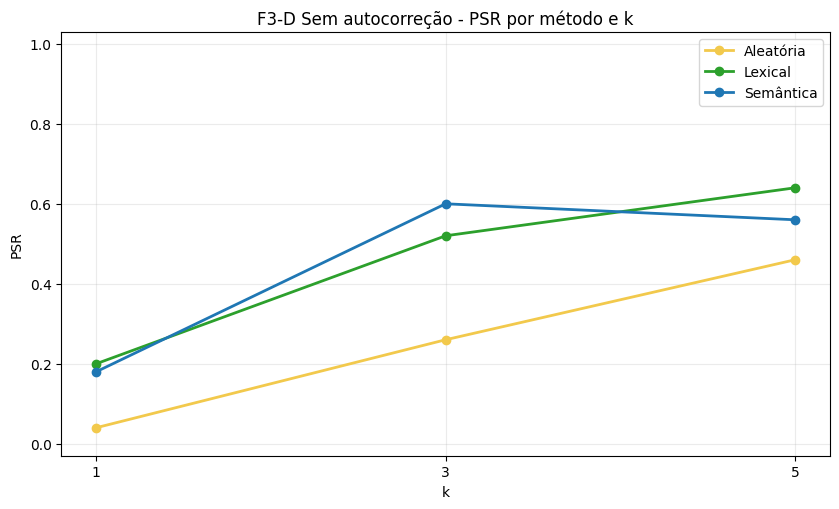

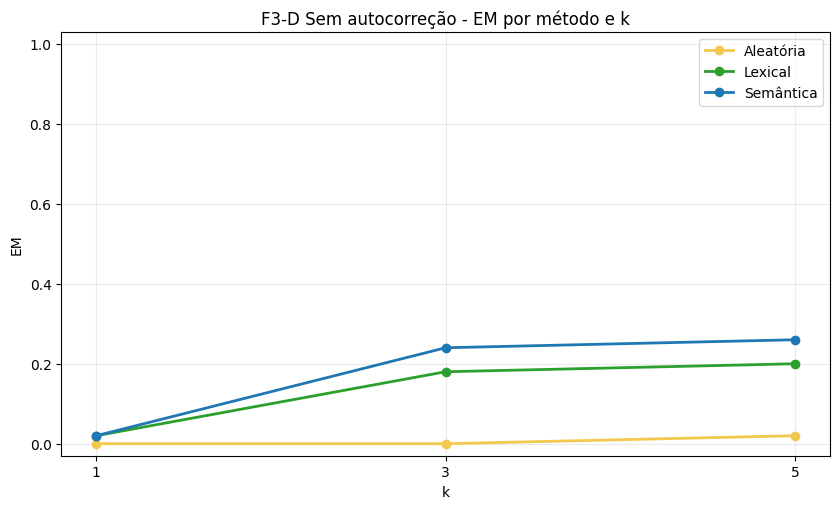

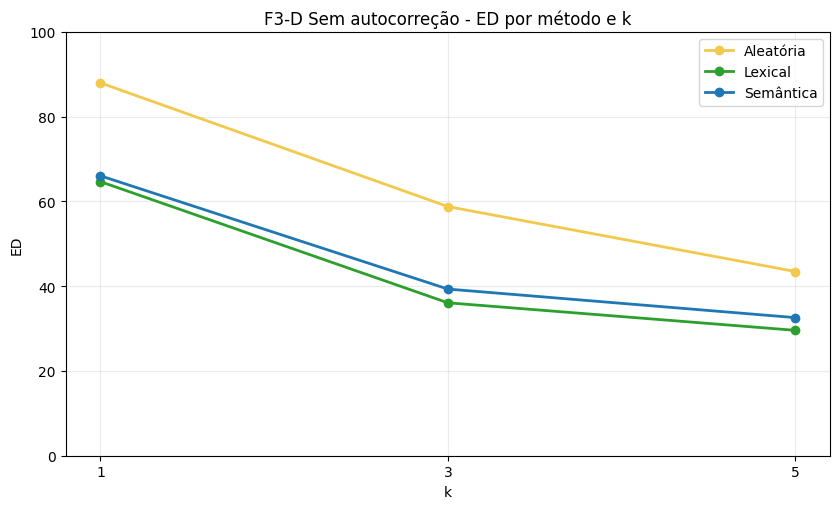

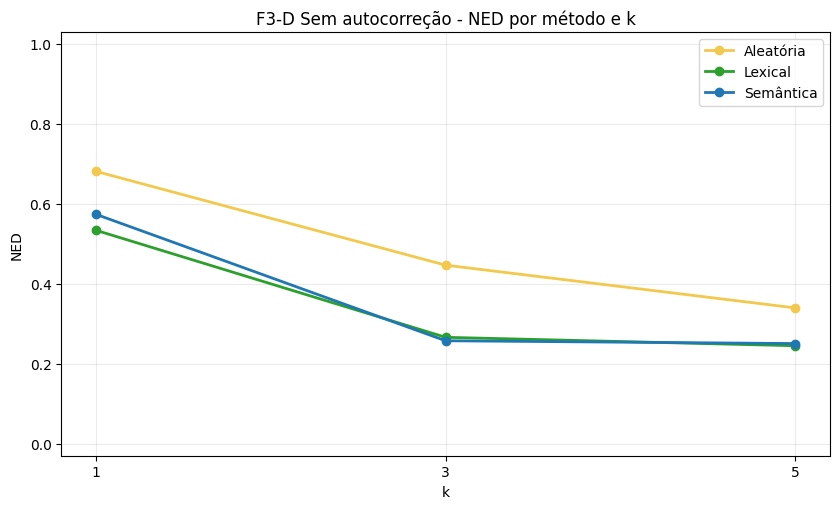

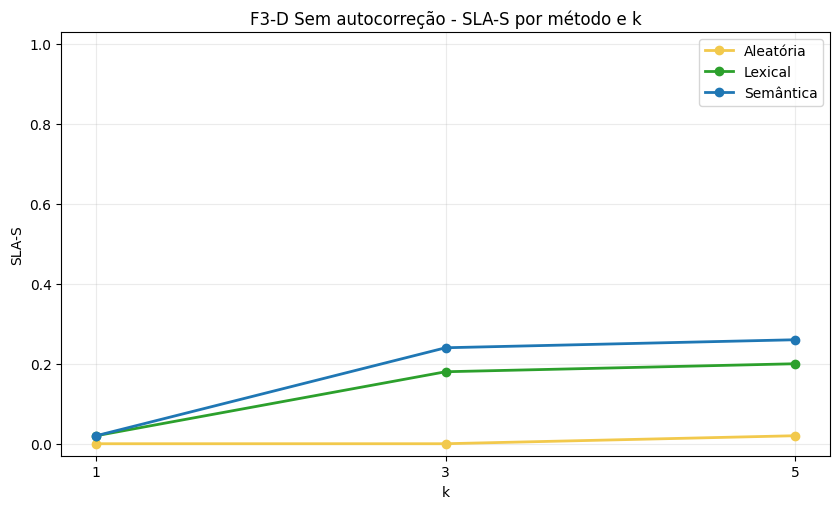

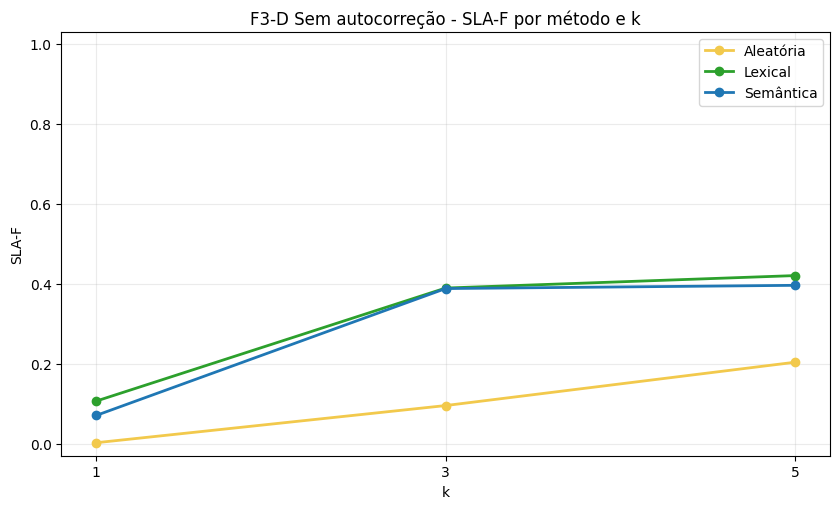

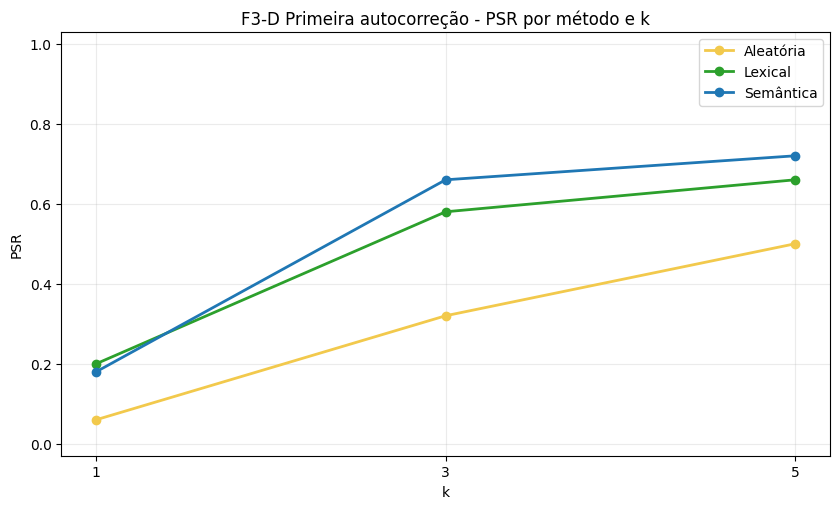

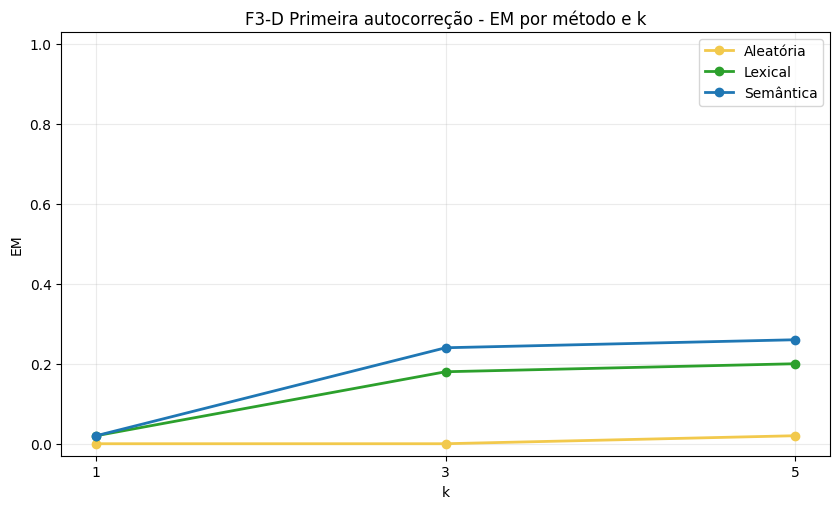

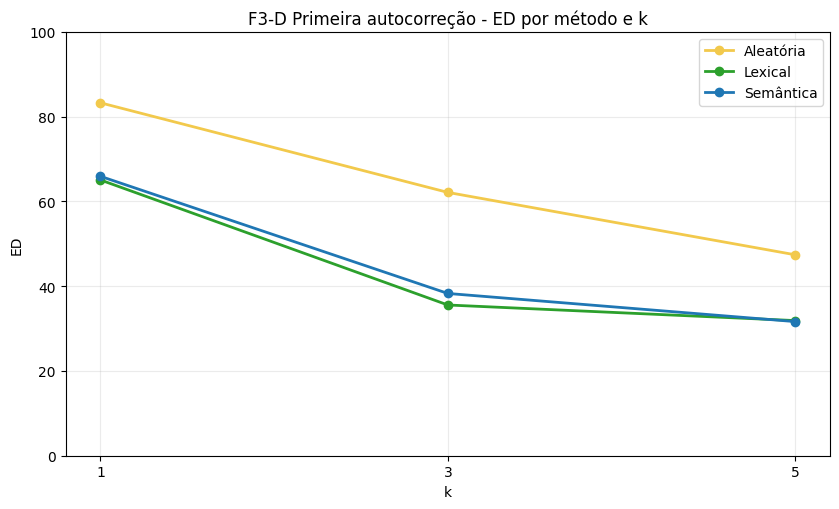

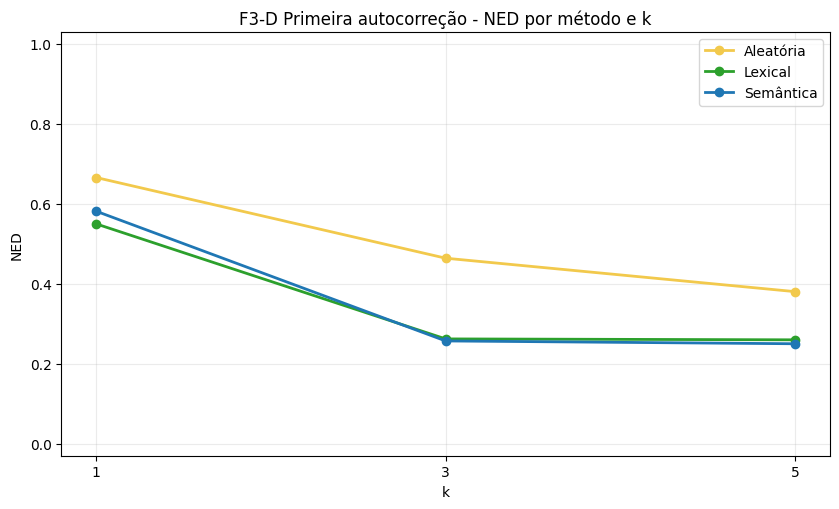

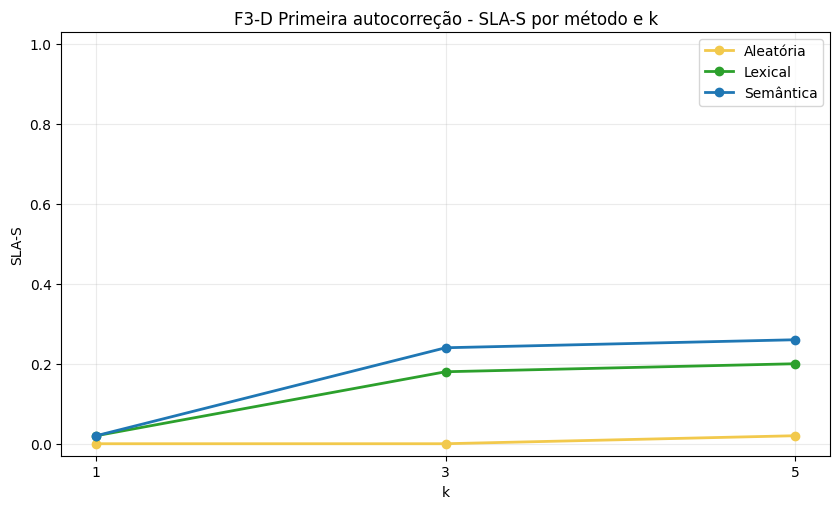

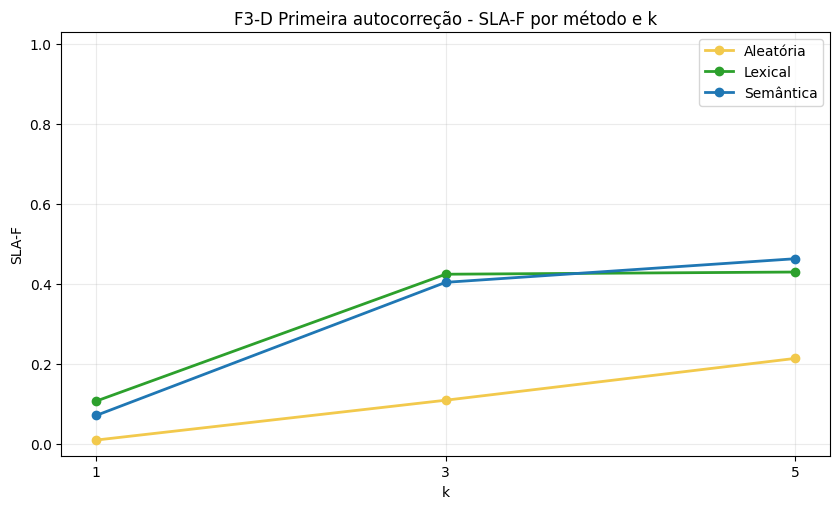

Bloco 9 concluído.
Condições resumidas: 18
Gráficos produzidos: 12
Escalas fixas aplicadas: PSR, EM, NED, SLA-S e SLA-F de 0 a 1; ED de 0 a 100.
Saídas rejeitadas pelo parser após a primeira autocorreção: 256
Elegíveis à autocorreção final por PSR=0: 256
Status: OK


In [9]:
# ----------------------------------------------------------
# 9.1 Resumos por condição e por fold
# ----------------------------------------------------------

summary_df = (
    results_df
    .groupby(
        [
            "variant",
            "selection_method",
            "selection_label",
            "k",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        prompt_primary_tokens=("prompt_primary_tokens", "mean"),
        prompt_autocorrection_tokens=(
            "prompt_autocorrection_tokens",
            "mean",
        ),
        elapsed_primary_seconds=("elapsed_primary_seconds", "mean"),
        elapsed_autocorrection_seconds=(
            "elapsed_autocorrection_seconds",
            "mean",
        ),
    )
    .reset_index()
)
summary_df["_ordem_variante"] = (
    summary_df["variant"].map(ORDEM_VARIANTES_MAPA)
)
summary_df["_ordem_metodo"] = (
    summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
summary_df = (
    summary_df
    .sort_values(["_ordem_variante", "k", "_ordem_metodo"])
    .drop(columns=["_ordem_variante", "_ordem_metodo"])
    .reset_index(drop=True)
)
summary_df.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8",
)

summary_fold_df = (
    results_df
    .groupby(
        [
            "fold",
            "variant",
            "selection_method",
            "selection_label",
            "k",
        ],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)
summary_fold_df["_ordem_variante"] = (
    summary_fold_df["variant"].map(ORDEM_VARIANTES_MAPA)
)
summary_fold_df["_ordem_metodo"] = (
    summary_fold_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
summary_fold_df = (
    summary_fold_df
    .sort_values(
        ["fold", "_ordem_variante", "k", "_ordem_metodo"]
    )
    .drop(columns=["_ordem_variante", "_ordem_metodo"])
    .reset_index(drop=True)
)
summary_fold_df.to_csv(
    SUMMARY_FOLD_PATH,
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 9.2 Saídas inválidas, elegibilidade final e ganhos
# ----------------------------------------------------------

invalid_sem_ac_df = results_df.loc[
    (results_df["variant"] == "sem_ac")
    & (~results_df["syntax_valid"].astype(bool))
].copy()
invalid_primeira_ac_df = results_df.loc[
    (results_df["variant"] == "primeira_ac")
    & (~results_df["syntax_valid"].astype(bool))
].copy()

for frame in [invalid_sem_ac_df, invalid_primeira_ac_df]:
    frame["_ordem_metodo"] = (
        frame["selection_method"].map(ORDEM_METODOS_MAPA)
    )
    frame.sort_values(
        ["fold", "k", "_ordem_metodo", "id"],
        inplace=True,
    )
    frame.drop(columns="_ordem_metodo", inplace=True)
    frame.reset_index(drop=True, inplace=True)

invalid_sem_ac_df.to_csv(
    INVALID_SEM_AC_PATH,
    index=False,
    encoding="utf-8",
)
invalid_primeira_ac_df.to_csv(
    INVALID_PRIMEIRA_AC_PATH,
    index=False,
    encoding="utf-8",
)

final_ac_eligible_df = results_df.loc[
    (results_df["variant"] == "primeira_ac")
    & (results_df["psr"] == 0)
].copy()
final_ac_eligible_df["_ordem_metodo"] = (
    final_ac_eligible_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
final_ac_eligible_df = (
    final_ac_eligible_df
    .sort_values(["fold", "k", "_ordem_metodo", "id"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
final_ac_eligible_df.to_csv(
    FINAL_AC_ELIGIBLE_PATH,
    index=False,
    encoding="utf-8",
)

gains_df = (
    comparison_df
    .groupby(
        ["selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        autocorrections=("autocorrection_applied", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
        psr_before=("psr_before", "mean"),
        psr_after=("psr_after", "mean"),
        em_before=("em_before", "mean"),
        em_after=("em_after", "mean"),
        ed_before=("ed_before", "mean"),
        ed_after=("ed_after", "mean"),
        ned_before=("ned_before", "mean"),
        ned_after=("ned_after", "mean"),
        sla_s_before=("sla_s_before", "mean"),
        sla_s_after=("sla_s_after", "mean"),
        sla_f_before=("sla_f_before", "mean"),
        sla_f_after=("sla_f_after", "mean"),
    )
    .reset_index()
)
for metric in METRICAS:
    gains_df[f"delta_{metric}"] = (
        gains_df[f"{metric}_after"]
        - gains_df[f"{metric}_before"]
    )

gains_df["_ordem_metodo"] = (
    gains_df["selection_method"].map(ORDEM_METODOS_MAPA)
)
gains_df = (
    gains_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
gains_df.to_csv(
    GAINS_PATH,
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 9.3 Análise por exemplo e auditoria de execução
# ----------------------------------------------------------

analysis_long_df = (
    results_df
    .groupby(["id", "variant"], dropna=False)
    .agg(
        records=("k", "count"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)
analysis_example_df = analysis_long_df.pivot(
    index="id",
    columns="variant",
)
analysis_example_df.columns = [
    f"{metric}_{variant}"
    for metric, variant in analysis_example_df.columns
]
analysis_example_df = (
    analysis_example_df
    .reset_index()
    .sort_values("id")
    .reset_index(drop=True)
)
analysis_example_df.to_csv(
    ANALYSIS_EXAMPLE_PATH,
    index=False,
    encoding="utf-8",
)

execution_audit_df = (
    comparison_df
    .groupby(
        ["selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        syntax_valid_before=("psr_before", "sum"),
        syntax_valid_after=("psr_after", "sum"),
        autocorrections=("autocorrection_applied", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
)
execution_audit_df["_ordem_metodo"] = (
    execution_audit_df["selection_method"]
    .map(ORDEM_METODOS_MAPA)
)
execution_audit_df = (
    execution_audit_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
execution_audit_df.to_csv(
    EXECUTION_AUDIT_PATH,
    index=False,
    encoding="utf-8",
)


# ----------------------------------------------------------
# 9.4 Tabelas principais
# ----------------------------------------------------------

summary_sem_df = summary_df.loc[
    summary_df["variant"] == "sem_ac"
].copy()
summary_ac_df = summary_df.loc[
    summary_df["variant"] == "primeira_ac"
].copy()

exibir_tabela(
    summary_sem_df,
    "Desempenho da F3-D sem autocorreção",
)
exibir_tabela(
    summary_ac_df,
    "Desempenho da F3-D com primeira autocorreção",
)
exibir_tabela(
    gains_df,
    "Ganhos da primeira autocorreção",
    altura_px=420,
)
exibir_tabela(
    summary_fold_df,
    "Desempenho por fold, variante, método e k",
    altura_px=520,
)


# ----------------------------------------------------------
# 9.5 Gráficos das métricas com escalas fixas
# ----------------------------------------------------------

import matplotlib.pyplot as plt

LIMITES_EIXO_Y = {
    "psr": (-0.03, 1.03),
    "em": (-0.03, 1.03),
    "ed": (0.0, 100.0),
    "ned": (-0.03, 1.03),
    "sla_s": (-0.03, 1.03),
    "sla_f": (-0.03, 1.03),
}

TICKS_EIXO_Y = {
    "psr": np.arange(0.0, 1.01, 0.2),
    "em": np.arange(0.0, 1.01, 0.2),
    "ed": np.arange(0.0, 100.1, 20.0),
    "ned": np.arange(0.0, 1.01, 0.2),
    "sla_s": np.arange(0.0, 1.01, 0.2),
    "sla_f": np.arange(0.0, 1.01, 0.2),
}


# ----------------------------------------------------------
# 9.5.1 Auditoria dos limites fixos
# ----------------------------------------------------------

auditoria_limites = []
for metric in METRICAS:
    limite_inferior, limite_superior = LIMITES_EIXO_Y[metric]
    valor_minimo = float(summary_df[metric].min())
    valor_maximo = float(summary_df[metric].max())
    dentro_do_limite = (
        valor_minimo >= limite_inferior
        and valor_maximo <= limite_superior
    )
    auditoria_limites.append({
        "métrica": ROTULOS_METRICAS[metric],
        "mínimo observado": valor_minimo,
        "máximo observado": valor_maximo,
        "limite inferior": limite_inferior,
        "limite superior": limite_superior,
        "dentro do limite": dentro_do_limite,
    })

auditoria_limites_df = pd.DataFrame(auditoria_limites)
if not auditoria_limites_df["dentro do limite"].all():
    metricas_fora = auditoria_limites_df.loc[
        ~auditoria_limites_df["dentro do limite"],
        "métrica",
    ].astype(str).tolist()
    raise ValueError(
        "Há métricas fora dos limites gráficos padronizados: "
        + ", ".join(metricas_fora)
        + ". Os limites devem ser revistos de forma global para "
        "todas as estratégias antes da geração dos gráficos."
    )

exibir_tabela(
    auditoria_limites_df,
    "Auditoria dos limites fixos dos gráficos",
)


# ----------------------------------------------------------
# 9.5.2 Geração dos doze gráficos
# ----------------------------------------------------------

GRAFICOS_PATHS = {}

for variant in ORDEM_VARIANTES_EXIBICAO:
    variant_df = summary_df.loc[
        summary_df["variant"] == variant
    ].copy()

    for metric in METRICAS:
        fig, ax = plt.subplots(figsize=(8.5, 5.2))

        for method in ORDEM_METODOS_EXIBICAO:
            method_df = (
                variant_df.loc[
                    variant_df["selection_method"] == method
                ]
                .sort_values("k")
            )
            if method_df.empty:
                continue

            ax.plot(
                method_df["k"],
                method_df[metric],
                marker="o",
                linewidth=2,
                label=ROTULOS_METODOS[method],
                color=CORES_METODOS[method],
            )

        ax.set_title(
            f"F3-D {ROTULOS_VARIANTES[variant]} - "
            f"{ROTULOS_METRICAS[metric]} por método e k"
        )
        ax.set_xlabel("k")
        ax.set_ylabel(ROTULOS_METRICAS[metric])
        ax.set_xticks(K_FEWSHOT)

        limite_inferior, limite_superior = LIMITES_EIXO_Y[metric]
        ax.set_ylim(limite_inferior, limite_superior)
        ax.set_yticks(TICKS_EIXO_Y[metric])

        ax.grid(True, alpha=0.25)
        ax.legend()
        fig.tight_layout()

        graph_path = (
            GRAFICOS_DIR
            / f"f3d_{variant}_{metric}.png"
        )
        fig.savefig(
            graph_path,
            dpi=160,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

        GRAFICOS_PATHS[(variant, metric)] = graph_path

print("Bloco 9 concluído.")
print(f"Condições resumidas: {len(summary_df)}")
print(f"Gráficos produzidos: {len(GRAFICOS_PATHS)}")
print(
    "Escalas fixas aplicadas: "
    "PSR, EM, NED, SLA-S e SLA-F de 0 a 1; "
    "ED de 0 a 100."
)
print(
    "Saídas rejeitadas pelo parser após a primeira autocorreção: "
    f"{len(invalid_primeira_ac_df)}"
)
print(
    "Elegíveis à autocorreção final por PSR=0: "
    f"{len(final_ac_eligible_df)}"
)
print("Status: OK")

## Bloco 10 - Barreiras finais, manifesto e empacotamento

### Objetivo

Este bloco encerra a F3-D e cria o pacote operacional utilizado na consolidação e na autocorreção final.

### Barreiras obrigatórias

O empacotamento exige:

- 450 fluxos-base;
- 450 prompts, gerações e avaliações iniciais;
- quantidade de autocorreções igual ao total de saídas iniciais com `PSR=0`;
- 900 resultados finais;
- 18 condições de 50 registros;
- 90 combinações por fold;
- 50 IDs na análise por exemplo;
- 12 gráficos;
- tokens idênticos entre auditoria e inferência;
- zero vazamento e zero placeholders;
- compatibilidade integral com o schema comum.

### Preservação

A variante `primeira_ac` deve ser idêntica à `sem_ac` quando não houver elegibilidade. A tentativa de autocorreção só pode ser registrada para saídas iniciais com `PSR=0`.

### Manifesto

O manifesto registra origem do F3-modelo, modelo aluno, uso de R3 apenas nas demonstrações, ausência de IR no fluxo, critérios de autocorreção, métricas, escalas dos gráficos, resultados observados e hashes dos artefatos.

### Pacote final

O arquivo produzido é:

```text
f3d_traducao_com_r3.zip
```

### Resultado esperado

A F3-D só é considerada concluída quando o ZIP pode ser reaberto, possui exatamente os arquivos previstos e todos os hashes conferem.

In [10]:
# ----------------------------------------------------------
# 10.1 Barreiras finais da execução oficial
# ----------------------------------------------------------

if MODO_TESTE_RAPIDO:
    raise RuntimeError(
        "O modo de teste rápido está ativo. Desative-o e execute "
        "os Blocos 6 a 10 para produzir o pacote oficial da F3-D."
    )

if len(plan_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("O pacote oficial exige 450 fluxos-base.")
if len(prompt_nile_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de prompts Nile é divergente.")
if len(nile_generation_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de gerações Nile é divergente.")
if len(initial_evaluation_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de avaliações iniciais é divergente.")

expected_autocorrections = int(
    initial_evaluation_df["eligible_for_autocorrection"].sum()
)
if len(prompt_ac_records) != expected_autocorrections:
    raise ValueError(
        "A quantidade de prompts de autocorreção é divergente."
    )
if len(ac_generation_records) != expected_autocorrections:
    raise ValueError(
        "A quantidade de gerações de autocorreção é divergente."
    )
if len(result_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 900 resultados.")
if (
    len(summary_df) != TOTAL_CONDICOES_ESPERADO
    or not summary_df["records"].eq(50).all()
):
    raise ValueError(
        "O resumo não contém 18 condições de 50 registros."
    )
if (
    len(summary_fold_df)
    != TOTAL_FOLDS_ESPERADO * TOTAL_CONDICOES_ESPERADO
):
    raise ValueError(
        "O resumo por fold não possui 90 combinações."
    )
if len(analysis_example_df) != TOTAL_EXEMPLOS_ESPERADO:
    raise ValueError("A análise por exemplo deve conter 50 IDs.")
if len(GRAFICOS_PATHS) != 12:
    raise ValueError("A F3-D deve produzir doze gráficos.")


def assert_token_consistency(
    prompt_records_stage,
    generation_records_stage,
    max_new_tokens,
):
    prompt_map = {
        str(record["execution_id"]): int(record["prompt_tokens"])
        for record in prompt_records_stage
    }
    generation_map = {
        str(record["execution_id"]): int(record["prompt_tokens"])
        for record in generation_records_stage
    }
    if prompt_map != generation_map:
        raise ValueError(
            "A auditoria de tokens diverge da inferência."
        )
    if (
        prompt_map
        and max(prompt_map.values()) + max_new_tokens > CONTEXT_LIMIT
    ):
        raise ValueError("Há prompt fora do limite de contexto.")


assert_token_consistency(
    prompt_nile_records,
    nile_generation_records,
    MAX_NEW_TOKENS_NILE,
)
assert_token_consistency(
    prompt_ac_records,
    ac_generation_records,
    MAX_NEW_TOKENS_NILE,
)

if results_df["status"].ne("completed").any():
    raise ValueError("Há resultados não concluídos.")
if results_df["strategy"].ne(ESTRATEGIA).any():
    raise ValueError("Há resultado associado a outra estratégia.")

for record in result_records:
    errors = sorted(
        result_validator.iter_errors(record),
        key=lambda error: list(error.path),
    )
    if errors:
        raise ValueError(
            "Há resultado incompatível com o schema comum."
        )

result_key_map = {}
for record in result_records:
    key = (
        int(record["fold"]),
        str(record["id"]),
        str(record["selection_method"]),
        int(record["k"]),
        str(record["variant"]),
    )
    if key in result_key_map:
        raise ValueError(f"Resultado duplicado para {key}.")
    result_key_map[key] = record

for plan in plan_records:
    base = (
        int(plan["fold"]),
        str(plan["id"]),
        str(plan["selection_method"]),
        int(plan["k"]),
    )
    sem = result_key_map[(*base, "sem_ac")]
    ac = result_key_map[(*base, "primeira_ac")]
    eligible = int(sem["psr"]) == 0

    if bool(ac["autocorrection_applied"]) != eligible:
        raise ValueError(
            f"Decisão de autocorreção divergente para {base}."
        )

    if not eligible:
        if ac["nile_evaluated"] != sem["nile_evaluated"]:
            raise ValueError(
                f"Saída preservada foi alterada para {base}."
            )
        if ac["prompt_autocorrection"] is not None:
            raise ValueError(
                f"Prompt de autocorreção indevido para {base}."
            )
        for metric in METRICAS:
            if not np.isclose(
                float(ac[metric]),
                float(sem[metric]),
                rtol=0,
                atol=1e-12,
            ):
                raise ValueError(
                    f"Métrica preservada foi alterada para {base}: {metric}."
                )

if prompt_audit_df["pending_placeholders"].astype(bool).any():
    raise ValueError("Há placeholders pendentes.")
for column in [
    "test_reference_nile_exposed",
    "test_reference_ir_exposed",
    "test_r1_exposed",
    "test_r2_exposed",
    "test_r3_exposed",
]:
    if prompt_audit_df[column].fillna(False).astype(bool).any():
        raise ValueError(f"Há exposição de referência em {column}.")
if not prompt_audit_df["context_ok"].astype(bool).all():
    raise ValueError("Há prompt fora do contexto.")


# ----------------------------------------------------------
# 10.2 Configuração consolidada
# ----------------------------------------------------------

def stage_token_stats(token_df):
    if token_df.empty:
        return {
            "prompts": 0,
            "min": None,
            "max": None,
            "max_reserved": None,
        }
    return {
        "prompts": int(len(token_df)),
        "min": int(token_df["prompt_tokens"].min()),
        "max": int(token_df["prompt_tokens"].max()),
        "max_reserved": int(token_df["reserved_tokens"].max()),
    }


config_final = {
    **configuracao_inicial,
    "inputs": {
        "f3_modelo_source": str(FONTE_F3_MODELO["path"]),
        "f3_modelo_source_type": FONTE_F3_MODELO["type"],
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
    },
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "source_used": str(MODEL_SOURCE),
        "source_type": MODEL_SOURCE_TYPE,
        "device": model_device,
        "dtype": model_dtype,
        "context_limit": CONTEXT_LIMIT,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "observed": {
        "base_pipelines": int(len(plan_records)),
        "final_results": int(len(result_records)),
        "syntax_valid_before": int(
            results_df.loc[
                results_df["variant"] == "sem_ac",
                "syntax_valid",
            ].sum()
        ),
        "syntax_valid_after": int(
            results_df.loc[
                results_df["variant"] == "primeira_ac",
                "syntax_valid",
            ].sum()
        ),
        "autocorrections_applied": expected_autocorrections,
        "syntax_recovered": int(
            comparison_df["syntax_recovered"].sum()
        ),
        "final_autocorrection_eligible": int(
            len(final_ac_eligible_df)
        ),
        "tokens": {
            "nl_r3_to_nile": stage_token_stats(token_audit_nile_df),
            "autocorrection": stage_token_stats(token_audit_ac_df),
        },
    },
}
write_json(config_final, CONFIG_PATH)


# ----------------------------------------------------------
# 10.3 Inventário e manifesto
# ----------------------------------------------------------

clean_runtime_caches(F3D_DIR)

package_files = [
    CONFIG_PATH,
    PLANO_PATH,
    PROMPTS_NILE_PATH,
    TOKEN_AUDIT_NILE_PATH,
    GENERATIONS_NILE_PATH,
    INITIAL_EVALUATION_PATH,
    PROMPTS_AC_PATH,
    TOKEN_AUDIT_AC_PATH,
    GENERATIONS_AC_PATH,
    PROMPT_AUDIT_PATH,
    RESULTS_JSONL_PATH,
    RESULTS_CSV_PATH,
    SUMMARY_PATH,
    SUMMARY_FOLD_PATH,
    INVALID_SEM_AC_PATH,
    INVALID_PRIMEIRA_AC_PATH,
    FINAL_AC_ELIGIBLE_PATH,
    ANALYSIS_EXAMPLE_PATH,
    EXECUTION_AUDIT_PATH,
    COMPARISON_PATH,
    GAINS_PATH,
    *[
        GRAFICOS_PATHS[(variant, metric)]
        for variant in ORDEM_VARIANTES_EXIBICAO
        for metric in METRICAS
    ],
]

missing_files = [
    str(path)
    for path in package_files
    if not Path(path).is_file()
]
if missing_files:
    raise FileNotFoundError(
        "Arquivos finais ausentes: " + ", ".join(missing_files)
    )

file_inventory = []
for path in package_files:
    path = Path(path)
    relative = (
        "graficos/" + path.name
        if path.is_relative_to(GRAFICOS_DIR)
        else path.relative_to(PACOTE_DIR).as_posix()
    )
    file_inventory.append({
        "file": relative,
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

manifest = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variants": VARIANTES,
    "description": NOME_ESTRATEGIA,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": DATASET,
    "inputs": {
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
        "f0_manifest_sha256": f3_modelo_manifest.get(
            "inputs",
            {},
        ).get("f0_manifest_sha256"),
        "f1_manifest_sha256": f3_modelo_manifest.get(
            "inputs",
            {},
        ).get("f1_manifest_sha256"),
        "f2_manifest_sha256": f3_modelo_manifest.get(
            "inputs",
            {},
        ).get("f2_manifest_sha256"),
    },
    "experimental_design": {
        "folds": TOTAL_FOLDS_ESPERADO,
        "examples": TOTAL_EXEMPLOS_ESPERADO,
        "base_conditions": TOTAL_CONDICOES_BASE,
        "conditions": TOTAL_CONDICOES_ESPERADO,
        "base_pipelines": TOTAL_FLUXOS_BASE_ESPERADO,
        "records": TOTAL_REGISTROS_ESPERADO,
        "k_values": K_FEWSHOT,
        "selection_methods": METODOS_FEWSHOT,
        "formal_equivalent_demonstrations_excluded": True,
    },
    "model": config_final["student_model"],
    "metrics": {
        "names": ["PSR", "EM", "ED", "NED", "SLA-S", "SLA-F"],
        "internal_fields": METRICAS,
        "embedding_metric_used": False,
        "graph_scales": {
            "psr": [0, 1],
            "em": [0, 1],
            "ed": [0, 100],
            "ned": [0, 1],
            "sla_s": [0, 1],
            "sla_f": [0, 1],
        },
    },
    "method": {
        "teacher_model_used_during_f3d": False,
        "fine_tuning_used": False,
        "intermediate_representation_used": False,
        "rationales_used_in_prompt": True,
        "rationale_type": "R3",
        "r3_used_only_in_training_demonstrations": True,
        "test_r3_used": False,
        "test_r1_used": False,
        "test_r2_used": False,
        "test_reference_ir_used": False,
        "autocorrection_used": True,
        "autocorrection_attempt": 1,
        "autocorrection_only_for_syntax_invalid_nile": True,
        "same_few_shot_ids_in_autocorrection": True,
        "test_reference_exposed": False,
        "checkpoint_resume_enabled": True,
    },
    "results": {
        "autocorrections_applied": expected_autocorrections,
        "syntax_valid_before": config_final["observed"][
            "syntax_valid_before"
        ],
        "syntax_valid_after": config_final["observed"][
            "syntax_valid_after"
        ],
        "syntax_recovered": config_final["observed"][
            "syntax_recovered"
        ],
        "final_autocorrection_eligible": config_final["observed"][
            "final_autocorrection_eligible"
        ],
    },
    "software": {
        "python": platform.python_version(),
        "numpy": package_version("numpy"),
        "pandas": package_version("pandas"),
        "torch": package_version("torch"),
        "transformers": package_version("transformers"),
        "jsonschema": package_version("jsonschema"),
        "lark": package_version("lark"),
        "matplotlib": package_version("matplotlib"),
    },
    "files": file_inventory,
}
write_json(manifest, MANIFEST_PATH)


# ----------------------------------------------------------
# 10.4 Criação e auditoria do ZIP final
# ----------------------------------------------------------

if ZIP_FINAL_PATH.exists():
    ZIP_FINAL_PATH.unlink()

with zipfile.ZipFile(
    ZIP_FINAL_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as package:
    for item in file_inventory:
        source_path = (
            GRAFICOS_DIR / Path(item["file"]).name
            if item["file"].startswith("graficos/")
            else PACOTE_DIR / item["file"]
        )
        package.write(source_path, arcname=item["file"])
    package.write(MANIFEST_PATH, arcname="manifest.json")

expected_members = sorted(
    [item["file"] for item in file_inventory]
    + ["manifest.json"]
)
with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    actual_members = sorted(
        name
        for name in package.namelist()
        if not name.endswith("/")
    )
    if actual_members != expected_members:
        raise ValueError(
            "A estrutura interna do ZIP é divergente."
        )

    manifest_zip = json.loads(
        package.read("manifest.json").decode("utf-8")
    )
    if manifest_zip.get("phase") != FASE:
        raise ValueError(
            "O manifesto do ZIP não pertence à F3-D."
        )

    for item in manifest_zip.get("files", []):
        payload = package.read(item["file"])
        if len(payload) != int(item["size_bytes"]):
            raise ValueError(
                f"Tamanho divergente no ZIP: {item['file']}"
            )
        if hashlib.sha256(payload).hexdigest() != item["sha256"]:
            raise ValueError(
                f"Hash divergente no ZIP: {item['file']}"
            )

final_summary_df = pd.DataFrame([
    {"item": "fluxos-base", "value": len(plan_records)},
    {"item": "resultados finais", "value": len(result_records)},
    {
        "item": "autocorreções executadas",
        "value": expected_autocorrections,
    },
    {
        "item": "validade sintática sem AC",
        "value": config_final["observed"]["syntax_valid_before"],
    },
    {
        "item": "validade sintática com AC",
        "value": config_final["observed"]["syntax_valid_after"],
    },
    {"item": "arquivos no ZIP", "value": len(expected_members)},
    {"item": "ZIP final", "value": str(ZIP_FINAL_PATH)},
])

exibir_tabela(final_summary_df, "Resumo final da F3-D")

print("Bloco 10 concluído.")
print(f"Manifesto: {MANIFEST_PATH}")
print(f"Pacote final: {ZIP_FINAL_PATH}")
print(f"Arquivos no ZIP: {len(expected_members)}")
print("Hashes e tamanhos: conferidos")
print("F3-D concluída e pronta para congelamento.")
print("Status: OK")

item,valor
fluxos-base,450
resultados finais,900
autocorreções executadas,277
validade sintática sem AC,173
validade sintática com AC,194
arquivos no ZIP,34
ZIP final,/kaggle/working/f3d_traducao_com_r3.zip


Bloco 10 concluído.
Manifesto: /kaggle/working/f3d_traducao_com_r3/pacote/manifest.json
Pacote final: /kaggle/working/f3d_traducao_com_r3.zip
Arquivos no ZIP: 34
Hashes e tamanhos: conferidos
F3-D concluída e pronta para congelamento.
Status: OK
